In [ ]:
import os, random, math
import numpy as np
import torch
import torchaudio
import torchaudio.functional as AF
import torchaudio.transforms as T
import librosa
import matplotlib.pyplot as plt
from collections import defaultdict
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ── Config ────────────────────────────────────────────────────────────────────
SAMPLE_RATE  = 16000
NUM_SAMPLES  = 64000
N_FFT        = 512
HOP_LENGTH   = 503
N_MELS       = 128
DATASET_ROOT = '/kaggle/input/datasets/sb99999/asvspoof19/LA'

# ── Helpers ───────────────────────────────────────────────────────────────────
def load_mel(filepath, stretch_rate=1.0):
    waveform, sr = torchaudio.load(filepath)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != SAMPLE_RATE:
        waveform = AF.resample(waveform, sr, SAMPLE_RATE)
    if abs(stretch_rate - 1.0) > 1e-3:
        wav_np   = waveform.squeeze(0).numpy()
        wav_np   = librosa.effects.time_stretch(wav_np, rate=stretch_rate)
        waveform = torch.from_numpy(wav_np).unsqueeze(0).float()
    if waveform.shape[1] < NUM_SAMPLES:
        repeats  = math.ceil(NUM_SAMPLES / waveform.shape[1])
        waveform = waveform.repeat(1, repeats)
    waveform = waveform[:, :NUM_SAMPLES]
    mel_fn = T.MelSpectrogram(
        sample_rate=SAMPLE_RATE, n_fft=N_FFT,
        hop_length=HOP_LENGTH, n_mels=N_MELS,
        f_min=0.0, f_max=float(SAMPLE_RATE) / 2.0)
    db_fn = T.AmplitudeToDB(top_db=80)
    mel   = db_fn(mel_fn(waveform)).squeeze(0).numpy()
    return mel

def read_protocol(path):
    entries = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            entries.append((
                parts[0], parts[1],
                'bonafide' if parts[4] == 'bonafide' else 'spoof',
                parts[3]
            ))
    return entries

def add_colourbar(fig, im, ax):
    divider = make_axes_locatable(ax)
    cax     = divider.append_axes('right', size='4%', pad=0.06)
    cbar    = fig.colorbar(im, cax=cax)
    cbar.set_label('Amplitude of each\nfrequency bin (dB)',
                   fontsize=7.5, color='#444444')
    cbar.ax.tick_params(labelsize=7, colors='#444444')
    return cbar

def style_ax(ax, title, title_color='#1a2535'):
    ax.set_title(title, fontsize=10, fontweight='bold',
                 color=title_color, pad=6)
    ax.set_xlabel('Time frame', fontsize=8, color='#555555')
    ax.set_ylabel('Mel frequency bin', fontsize=8, color='#555555')
    ax.tick_params(labelsize=7, colors='#555555')
    for spine in ax.spines.values():
        spine.set_edgecolor('#dddddd')


# ═══════════════════════════════════════════════════════════════════════════════
# Data loading
# ═══════════════════════════════════════════════════════════════════════════════

proto_path = os.path.join(
    DATASET_ROOT,
    'ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt'
)
audio_dir = os.path.join(DATASET_ROOT, 'ASVspoof2019_LA_train/flac')

entries = read_protocol(proto_path)

speaker_bonafide = defaultdict(list)
speaker_spoof    = defaultdict(list)
for spk, fname, label, sys_id in entries:
    if label == 'bonafide':
        speaker_bonafide[spk].append(fname)
    else:
        speaker_spoof[spk].append((fname, sys_id))

valid_speakers = [
    spk for spk in speaker_bonafide
    if spk in speaker_spoof and len(speaker_spoof[spk]) >= 4
]
print(f'Speakers with both bonafide and spoof: {len(valid_speakers)}')

random.seed(42)
chosen_speaker = random.choice(valid_speakers)
print(f'Chosen speaker: {chosen_speaker}')

bonafide_fname = random.choice(speaker_bonafide[chosen_speaker])
bonafide_path  = os.path.join(audio_dir, bonafide_fname + '.flac')

# One utterance per unique attack system, up to 3
spoof_by_system = defaultdict(list)
for fname, sid in speaker_spoof[chosen_speaker]:
    spoof_by_system[sid].append(fname)

unique_systems = sorted(spoof_by_system.keys())[:3]
spoof_samples  = [
    (random.choice(spoof_by_system[sid]), sid)
    for sid in unique_systems
]
print(f'Attack systems selected: {[sid for _, sid in spoof_samples]}')

spoof_paths = [
    (os.path.join(audio_dir, f + '.flac'), sid)
    for f, sid in spoof_samples
]

# Load mels
mel_bonafide = load_mel(bonafide_path)
mel_spoofs   = [(load_mel(p), sid) for p, sid in spoof_paths]

all_mels = [mel_bonafide] + [m for m, _ in mel_spoofs]
vmin     = min(m.min() for m in all_mels)
vmax     = max(m.max() for m in all_mels)


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Bonafide vs Spoof, 2×2 grid
# ═══════════════════════════════════════════════════════════════════════════════

fig1, axes1 = plt.subplots(2, 2, figsize=(9.5, 9.0))
fig1.subplots_adjust(
    left=0.07,  right=0.93,
    top=0.90,   bottom=0.12,
    hspace=0.55, wspace=0.55
)

panels = (
    [(mel_bonafide, 'Bonafide', '#1a6b3c')] +
    [(mel_s, f'Spoof — {sid}', '#8b1a1a') for mel_s, sid in mel_spoofs]
)

for ax, (mel, title, col) in zip(axes1.flatten(), panels):
    im = ax.imshow(mel, aspect='auto', origin='lower',
                   cmap='magma', vmin=vmin, vmax=vmax)
    style_ax(ax, title, col)
    ax.text(
        0.5, -0.20,
        f'Speaker {chosen_speaker}',
        transform=ax.transAxes,
        ha='center', fontsize=8, color='#444444', style='italic'
    )
    add_colourbar(fig1, im, ax)

fig1.suptitle(
    f'Log-Mel Spectrograms — Bonafide vs Spoof  ·  Speaker {chosen_speaker}\n'
    'ASVspoof 2019 LA Training Set  ·  '
    'Colour encodes amplitude of each frequency bin (dB)',
    fontsize=10, fontweight='bold', color='#1a2535'
)

fig1.savefig('/kaggle/working/sample_mels_bonafide_vs_spoof.png',
             dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: sample_mels_bonafide_vs_spoof.png')

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Same utterance at 1.0x, 0.8x, 1.2x
# ═══════════════════════════════════════════════════════════════════════════════

rates    = [1.0, 0.8, 1.2]
labels_r = ['Original (1.0×)', 'Slowed (0.8×)', 'Sped up (1.2×)']
colors_r = ['#0d1f33',         '#1a3d2e',        '#4a1010'        ]
notes    = {
    1.0: '64,000 samples · 4.0 s',
    0.8: 'Stretched → trimmed to 64,000 samples',
    1.2: 'Compressed → trimmed to 64,000 samples',
}

mels_tempo = [load_mel(bonafide_path, stretch_rate=r) for r in rates]
vmin_t     = min(m.min() for m in mels_tempo)
vmax_t     = max(m.max() for m in mels_tempo)

# ── Layout ────────────────────────────────────────────────────────────────────
fig2 = plt.figure(figsize=(18.0, 11.0))

gs = gridspec.GridSpec(
    2, 2,
    figure       = fig2,
    left         = 0.07,
    right        = 0.96,
    top          = 0.88,
    bottom       = 0.12,
    hspace       = 0.45,
    wspace       = 0.38,
    width_ratios = [1, 1],
    height_ratios= [1, 1],
)

ax_orig = fig2.add_subplot(gs[0, :])   # row 0 — original, full width (centred)
ax_slow = fig2.add_subplot(gs[1, 0])   # row 1 — slowed,   left
ax_fast = fig2.add_subplot(gs[1, 1])   # row 1 — sped up,  right

# ── Draw each panel ───────────────────────────────────────────────────────────
panels = [
    (ax_orig, mels_tempo[0], labels_r[0], colors_r[0], rates[0]),
    (ax_slow, mels_tempo[1], labels_r[1], colors_r[1], rates[1]),
    (ax_fast, mels_tempo[2], labels_r[2], colors_r[2], rates[2]),
]

for ax, mel, lbl, col, r in panels:

    im_t = ax.imshow(
        mel,
        aspect = 'auto',
        origin = 'lower',
        cmap   = 'magma',
        vmin   = vmin_t,
        vmax   = vmax_t,
    )

    ax.set_title(lbl, fontsize=13, fontweight='bold', color=col, pad=8)
    ax.tick_params(axis='both', labelsize=10, colors='#111111')

    for spine in ax.spines.values():
        spine.set_edgecolor('#222222')
        spine.set_linewidth(1.2)

    ax.text(
        0.5, -0.13,
        notes[r],
        transform  = ax.transAxes,
        ha         = 'center',
        fontsize   = 9,
        color      = '#222222',
        style      = 'italic',
    )

    cb = fig2.colorbar(im_t, ax=ax, fraction=0.03, pad=0.02)
    cb.ax.tick_params(labelsize=9, colors='#111111')
    cb.set_label(
        'Amplitude of each\nfrequency bin (dB)',
        fontsize = 8,
        color    = '#111111',
    )

# ── Title & save ──────────────────────────────────────────────────────────────
fig2.suptitle(
    'Effect of Tempo Perturbation on Log-Mel Spectrogram\n'
    f'Same utterance — Speaker {chosen_speaker} · ASVspoof 2019 LA · '
    'Colour encodes amplitude of each frequency bin (dB)',
    fontsize   = 13,
    fontweight = 'bold',
    color      = '#0a0f1a',
)

fig2.savefig(
    '/kaggle/working/sample_mels_tempo_perturbation.png',
    dpi         = 200,
    bbox_inches = 'tight',
    facecolor   = 'white',
)

plt.show()
print('Saved: sample_mels_tempo_perturbation.png')

In [ ]:
# Cell 1 — Environment check
import torch, sys
print(f'Python  : {sys.version.split()[0]}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('WARNING: No GPU — go to Runtime -> Change runtime type -> T4 GPU')


In [2]:
# Cell 2 — Install remaining dependencies
import subprocess, sys

pkgs = ['scikit-learn', 'matplotlib', 'scipy', 'librosa']

subprocess.run([
    sys.executable, '-m', 'pip', 'install',
    *pkgs,
    '--quiet'
], check=True)

print('All extra packages installed.')

All extra packages installed.


In [3]:
import torch
import torchaudio

print("Torch version:", torch.__version__)
print("Torchaudio version:", torchaudio.__version__)

Torch version: 2.5.1+cu121
Torchaudio version: 2.5.1+cu121


In [4]:
# Cell 3 — Imports
import os, csv, random, math, warnings, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as AF
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from scipy.stats import norm as scipy_norm
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve
from e2cnn import gspaces as e2_gspaces
from e2cnn import nn as e2nn
from e2cnn.nn import FieldType, GeometricTensor
from escnn import gspaces as enn_gspaces
from escnn import nn as enn

warnings.filterwarnings('ignore')
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    import matplotlib; matplotlib.use('Agg')

import torch
torch.backends.cudnn.benchmark = False

print('Imports OK.')


2026-04-01 22:19:03.537378: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775081943.710029     375 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775081943.760536     375 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775081944.183827     375 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775081944.183857     375 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775081944.183860     375 computation_placer.cc:177] computation placer alr

Imports OK.


In [6]:
# Cell 4 — Configuration
# ════════════════════════════════════════════════════════════════
# DATASET_ROOT : path to extracted LA folder on Drive
# OUTPUT_DIR   : local fast storage used during training
# OUTPUT_DIR_DRIVE : permanent Drive backup copied after each model trains
# ════════════════════════════════════════════════════════════════
DATASET_ROOT     = '/kaggle/input/datasets/sb99999/asvspoof19/LA'
OUTPUT_DIR       = '/kaggle/working/outputs'
EVAL_MEL_DIR     = '/kaggle/input/datasets/sam8452/eval-mel-dataset/eval_mel_dataset'

os.makedirs(OUTPUT_DIR,       exist_ok=True)

# ── Audio preprocessing ──────────────────────────────────────────
# 4 seconds at 16 kHz = 64,000 samples
# hop_length=503 gives floor(64000/503)+1 = 128 time frames exactly
SAMPLE_RATE  = 16000
NUM_SAMPLES  = 64000
N_FFT        = 512
HOP_LENGTH   = 503
N_MELS       = 128
# Output mel shape: (1, 128, 128)

# ── Training ─────────────────────────────────────────────────────
BATCH_SIZE    = 64
EPOCHS        = 100
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 20
NUM_WORKERS   = 4
RANDOM_SEED   = 0

# ── 10% subset (set to 1.0 once pipeline is verified) ────────────
TRAIN_FRACTION = 1.0
DEV_FRACTION   = 1.0
EVAL_FRACTION  = 1.0

# ── Architecture ─────────────────────────────────────────────────
CNN_CHANNELS = [128, 128, 256, 256]
CNN_FC_HIDDEN = 128
GCNN_FIELDS  = [8,  16,  32,  32]
SO2_FIELDS = [6, 12, 24, 24]   

# ── DCF cost parameters (ASVspoof 2019 official) ─────────────────
DCF_C_MISS   = 1
DCF_C_FA     = 10
DCF_PI_SPOOF = 0.05

# ── Evaluation stretch rates ──────────────────────────────────────
# Fixed random test rates — reproducible, outside training augmentation range
_rng           = np.random.RandomState(0)
TEST_RATE_SLOW = float(_rng.uniform(0.5, 1.0))
TEST_RATE_FAST = float(_rng.uniform(1.0, 1.5))
print(f'Test rate slow : {TEST_RATE_SLOW:.4f}x')
print(f'Test rate fast : {TEST_RATE_FAST:.4f}x')

# ─────────────────────────────────────────────────────────────────
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = torch.cuda.is_available()
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f'Device          : {DEVICE}')
print(f'Dataset root    : {DATASET_ROOT}')
print(f'Output (local)  : {OUTPUT_DIR}')
print(f'NUM_WORKERS     : {NUM_WORKERS}')
print(f'PIN_MEMORY      : {PIN_MEMORY}')
frames = math.floor(NUM_SAMPLES / HOP_LENGTH) + 1
print(f'Mel shape       : (1, {N_MELS}, {frames})  <- must be (1, 128, 128)')
assert frames == 128, f'Expected 128 frames, got {frames}. Check HOP_LENGTH.'
print('Configuration OK.')


Test rate slow : 0.7744x
Test rate fast : 1.3576x
Device          : cuda
Dataset root    : /kaggle/input/datasets/sb99999/asvspoof19/LA
Output (local)  : /kaggle/working/outputs
NUM_WORKERS     : 4
PIN_MEMORY      : True
Mel shape       : (1, 128, 128)  <- must be (1, 128, 128)
Configuration OK.


In [7]:
# Cell 5 — Data pipeline

import gc

def read_protocol(path):
    # Protocol format: SPEAKER_ID  FILE_NAME  SYSTEM_ID  -  KEY
    # Returns list of (file_name, label, system_id)
    # label: 0 = bonafide,  1 = spoof
    entries = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            label = 0 if parts[4] == 'bonafide' else 1
            entries.append((parts[1], label, parts[3]))  # <-- parts[3] not parts[2]
    return entries


def load_mel(filepath, stretch_rate=1.0):
    # Load a .flac file and return mel spectrogram of shape (1, 128, 128).
    #
    # Time stretching via resample trick:
    #   new_len = int(orig_len / rate)
    #   rate=0.8 -> new_len > orig_len -> audio is slower (stretched)
    #   rate=1.2 -> new_len < orig_len -> audio is faster (compressed)
    #   AF.resample(waveform, orig_len, new_len) does the resampling.
    #
    # Short clips: repeat end-to-end until >= NUM_SAMPLES then trim.
    # Long clips : take first NUM_SAMPLES samples.

    waveform, sr = torchaudio.load(filepath)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sr != SAMPLE_RATE:
        waveform = AF.resample(waveform, sr, SAMPLE_RATE)

    if abs(stretch_rate - 1.0) > 1e-3:
        wav_np   = waveform.squeeze(0).numpy()
        wav_np   = librosa.effects.time_stretch(wav_np, rate=stretch_rate)
        waveform = torch.from_numpy(wav_np).unsqueeze(0).float()

    if waveform.shape[1] < NUM_SAMPLES:
        repeats  = math.ceil(NUM_SAMPLES / waveform.shape[1])
        waveform = waveform.repeat(1, repeats)

    waveform = waveform[:, :NUM_SAMPLES]

    mel_fn = T.MelSpectrogram(
        sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, f_min=0.0, f_max=float(SAMPLE_RATE) / 2.0)
    db_fn  = T.AmplitudeToDB(top_db=80)
    mel    = db_fn(mel_fn(waveform))
    mel    = (mel - mel.mean()) / (mel.std() + 1e-8)
    del waveform
    gc.collect()    
    return mel   # (1, 128, 128)

CACHE_DIR = '/kaggle/working/mel_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

def apply_additive_noise(waveform, snr_db):
    # Add white Gaussian noise at specified SNR in dB
    # snr_db: signal to noise ratio — lower means more noise
    signal_power = waveform.pow(2).mean()
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise        = torch.randn_like(waveform) * torch.sqrt(noise_power)
    return waveform + noise

def apply_audio_dropout(waveform, sr=16000,
                        num_dropouts=3,
                        min_ms=20, max_ms=200,
                        seed=42):
    # Replace random segments with silence
    # num_dropouts: number of dropout events
    # min_ms, max_ms: duration range of each dropout in milliseconds
    rng      = np.random.RandomState(seed)
    wav      = waveform.clone()
    min_samp = int(min_ms * sr / 1000)
    max_samp = int(max_ms * sr / 1000)
    length   = wav.shape[1]
    for _ in range(num_dropouts):
        duration = rng.randint(min_samp, max_samp)
        start    = rng.randint(0, max(1, length - duration))
        wav[:, start:start + duration] = 0.0
    return wav


from multiprocessing import Pool

def cache_one_file(args):
    split, fname, audio_dir, rate, cache_dir, sample_rate, num_samples, n_fft, hop_length, n_mels = args
    import torch, torchaudio, torchaudio.functional as AF
    import torchaudio.transforms as T
    import librosa, math, gc, numpy as np, os

    key  = f'{split}_{fname}_{rate}'
    path = os.path.join(cache_dir, key + '.pt')
    if os.path.exists(path):
        return 'skip'
    try:
        waveform, sr = torchaudio.load(os.path.join(audio_dir, fname + '.flac'))
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        if sr != sample_rate:
            waveform = AF.resample(waveform, sr, sample_rate)
        if abs(rate - 1.0) > 1e-3:
            wav_np   = waveform.squeeze(0).numpy()
            wav_np   = librosa.effects.time_stretch(wav_np, rate=rate)
            waveform = torch.from_numpy(wav_np).unsqueeze(0).float()
        if waveform.shape[1] < num_samples:
            repeats  = math.ceil(num_samples / waveform.shape[1])
            waveform = waveform.repeat(1, repeats)
        waveform = waveform[:, :num_samples]
        mel_fn = T.MelSpectrogram(sample_rate=sample_rate, n_fft=n_fft,
                    hop_length=hop_length, n_mels=n_mels,
                    f_min=0.0, f_max=float(sample_rate)/2.0)
        db_fn  = T.AmplitudeToDB(top_db=80)
        mel    = db_fn(mel_fn(waveform))
        mel    = (mel - mel.mean()) / (mel.std() + 1e-8)
        torch.save(mel, path)
        return 'done'
    except Exception as e:
        return f'error: {e}'

def cache_parallel(split, rates, fraction, n_workers=4):
    audio_sub, proto_sub = ASVspoofDataset.SPLITS[split]
    entries = read_protocol(os.path.join(DATASET_ROOT, proto_sub))
    if fraction < 1.0:
        rng = random.Random(RANDOM_SEED)
        rng.shuffle(entries)
        entries = entries[:max(1, int(len(entries) * fraction))]
    audio_dir = os.path.join(DATASET_ROOT, audio_sub)
    args = [
        (split, fname, audio_dir, rate, CACHE_DIR,
         SAMPLE_RATE, NUM_SAMPLES, N_FFT, HOP_LENGTH, N_MELS)
        for fname, _, _ in entries
        for rate in rates
    ]
    done = skip = err = 0
    for i, arg in enumerate(args):
        result = cache_one_file(arg)
        if result == 'skip':   skip += 1
        elif result == 'done': done += 1
        else:                  err  += 1
        if i % 500 == 0:
            print(f'  {i}/{len(args)}  done={done} skip={skip} err={err}')
    print(f'Finished: done={done} skip={skip} err={err}')

class ASVspoofDataset(Dataset):
    # ASVspoof 2019 LA dataset.
    # train split : A01-A06 spoofing systems (6 systems)
    # dev split   : A01-A06 (same systems, used for validation during training)
    # eval split  : A07-A19 (13 unseen systems, used only for final reporting)
    SPLITS = {
        'train': ('ASVspoof2019_LA_train/flac',
                  'ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt'),
        'dev':   ('ASVspoof2019_LA_dev/flac',
                  'ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt'),
        'eval':  ('ASVspoof2019_LA_eval/flac',
                  'ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt'),
    }

    def __init__(self, root, split, augment=False, stretch=1.0, fraction=1.0):
        # augment=True  : Model 2 training — each file -> 3 versions
        #                 stretch rates [1.0, 0.8, 1.2], dataset is 3x larger
        # stretch=rate  : fixed stretch for eval conditions 
        # fraction      : 0.10 for 10% subset during development

        self.split = split   # add this
        audio_sub, proto_sub = self.SPLITS[split]
        self.audio_dir = os.path.join(root, audio_sub)
        self.augment   = augment

        entries = read_protocol(os.path.join(root, proto_sub))

        if fraction < 1.0:
            rng = random.Random(RANDOM_SEED)
            rng.shuffle(entries)
            entries = entries[:max(1, int(len(entries) * fraction))]

        if augment:
            # Original + 0.8x + 1.2x for every file
            self.samples = [(*e, r) for e in entries for r in [1.0, 0.8, 1.2]]
        else:
            self.samples = [(*e, stretch) for e in entries]

    def __len__(self):
        return len(self.samples)

    '''
    def __getitem__(self, idx):
        fname, label, sys_id, stretch = self.samples[idx]
        filepath = os.path.join(self.audio_dir, fname + '.flac')
        mel = load_mel(filepath, stretch_rate=stretch)
        return mel, label, sys_id
    '''
    
    def __getitem__(self, idx):
        fname, label, sys_id, stretch = self.samples[idx]
    
        # Eval split loads from pre-generated dataset
        if self.split == 'eval':
            key  = f'eval_{fname}_{stretch}'
            path = os.path.join(EVAL_MEL_DIR, key + '.pt')
            if os.path.exists(path):
                mel = torch.load(path, weights_only=True).float()
                return mel, label, sys_id
    
        # Train and dev use session cache or on-the-fly
        key  = f'{self.split}_{fname}_{stretch}'
        path = os.path.join(CACHE_DIR, key + '.pt')
        if os.path.exists(path):
            mel = torch.load(path, weights_only=True)
        else:
            filepath = os.path.join(self.audio_dir, fname + '.flac')
            mel = load_mel(filepath, stretch_rate=stretch)
        return mel, label, sys_id

def get_loaders(augment_train=False, eval_stretch=1.0):
    # augment_train=True  : use for Model 2 training only
    # eval_stretch        : 1.0 / 0.8 / 1.2 for the three eval conditions
    # dev split is never augmented and uses DEV_FRACTION for speed
    train_ds = ASVspoofDataset(DATASET_ROOT, 'train',
                               augment=augment_train,
                               fraction=TRAIN_FRACTION)
    dev_ds   = ASVspoofDataset(DATASET_ROOT, 'dev',
                               fraction=DEV_FRACTION)
    eval_ds  = ASVspoofDataset(DATASET_ROOT, 'eval',
                               stretch=eval_stretch,
                               fraction=EVAL_FRACTION)
    kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
              pin_memory=PIN_MEMORY)
    return (DataLoader(train_ds, shuffle=True,  **kw),
            DataLoader(dev_ds,   shuffle=False, **kw),
            DataLoader(eval_ds,  shuffle=False, **kw))


class AugmentedEvalDataset(Dataset):
    # Eval dataset with real-world augmentation applied on the fly
    # augmentation: 'noise_20db', 'noise_10db', 'noise_0db',
    #               'codec_32k', 'codec_16k', 'codec_8k',
    #               'dropout'
    SPLITS = ASVspoofDataset.SPLITS

    def __init__(self, root, augmentation, fraction=1.0):
        self.augmentation = augmentation
        audio_sub, proto_sub = self.SPLITS['eval']
        self.audio_dir = os.path.join(root, audio_sub)

        entries = read_protocol(os.path.join(root, proto_sub))
        if fraction < 1.0:
            rng = random.Random(RANDOM_SEED)
            rng.shuffle(entries)
            entries = entries[:max(1, int(len(entries) * fraction))]

        self.samples = entries

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label, sys_id = self.samples[idx]
        filepath = os.path.join(self.audio_dir, fname + '.flac')

        # Load raw waveform
        waveform, sr = torchaudio.load(filepath)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        if sr != SAMPLE_RATE:
            waveform = AF.resample(waveform, sr, SAMPLE_RATE)
        if waveform.shape[1] < NUM_SAMPLES:
            repeats  = math.ceil(NUM_SAMPLES / waveform.shape[1])
            waveform = waveform.repeat(1, repeats)
        waveform = waveform[:, :NUM_SAMPLES]

        # Apply augmentation
        if self.augmentation == 'noise_20db':
            waveform = apply_additive_noise(waveform, snr_db=20)
        elif self.augmentation == 'noise_10db':
            waveform = apply_additive_noise(waveform, snr_db=10)
        elif self.augmentation == 'noise_0db':
            waveform = apply_additive_noise(waveform, snr_db=0)
        elif self.augmentation == 'dropout':
            waveform = apply_audio_dropout(waveform)

        # Convert to mel spectrogram
        mel_fn = T.MelSpectrogram(
            sample_rate=SAMPLE_RATE, n_fft=N_FFT,
            hop_length=HOP_LENGTH, n_mels=N_MELS,
            f_min=0.0, f_max=float(SAMPLE_RATE) / 2.0)
        db_fn  = T.AmplitudeToDB(top_db=80)
        mel    = db_fn(mel_fn(waveform))
        mel    = (mel - mel.mean()) / (mel.std() + 1e-8)
        return mel, label, sys_id


def get_augmented_eval_loader(augmentation, fraction=0.1):
    ds = AugmentedEvalDataset(
        DATASET_ROOT, augmentation,
        fraction=fraction
    )
    return DataLoader(
        ds, batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )


# New Cell — Precomputed Eval Dataset
class EvalMelDataset(Dataset):
    def __init__(self, mel_dir, protocol_path, rate):
        self.mel_dir = mel_dir
        self.entries = []
        self.rate = rate
    
        # Build a lookup dict ONCE instead of os.listdir() per entry
        rate_str = str(rate)
        available = {
            f: True
            for f in os.listdir(mel_dir)
            if f.endswith('.pt') and rate_str in f
        }
    
        with open(protocol_path) as f:
            for i, line in enumerate(f):
                if i % 5000 == 0:
                    print(f'  Processed {i} protocol entries...')
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
    
                fname  = parts[1]
                label  = 0 if parts[4] == 'bonafide' else 1
                sys_id = parts[3]
    
                # O(1) lookup instead of O(N) scan
                key  = f'eval_{fname}_{rate}.pt'
                path = os.path.join(mel_dir, key)
                if key in available:
                    self.entries.append((path, label, sys_id))

        print(f'Loaded {len(self.entries)} samples for rate={rate}')

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        path, label, sys_id = self.entries[idx]
        mel = torch.load(path)  # already normalized float16

        mel = mel.float()  # convert back to float32 for model
        return mel, label, sys_id

from torch.utils.data import DataLoader

def get_precomputed_loader(rate):
    dataset = EvalMelDataset(
        mel_dir=EVAL_MEL_DIR,
        protocol_path=EVAL_PROTO,
        rate=rate
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return loader



print('Data pipeline defined. Checking paths...')
all_ok = True
for split, (audio_sub, proto_sub) in ASVspoofDataset.SPLITS.items():
    a_ok = os.path.isdir(os.path.join(DATASET_ROOT, audio_sub))
    p_ok = os.path.isfile(os.path.join(DATASET_ROOT, proto_sub))
    print(f'  {split:5s}  audio: {"OK" if a_ok else "NOT FOUND"}  '
          f'protocol: {"OK" if p_ok else "NOT FOUND"}')
    if not a_ok or not p_ok: all_ok = False
asv_p = os.path.join(DATASET_ROOT, 'ASVspoof2019_LA_asv_scores',
                     'ASVspoof2019.LA.asv.eval.gi.trl.scores.txt')
asv_ok = os.path.isfile(asv_p)
print(f'  t-DCF ASV scores: {"OK" if asv_ok else "NOT FOUND (t-DCF will be skipped)"}')
if not all_ok:
    print('\nFix path errors before continuing.')
else:
    print('\nAll paths OK.')


Data pipeline defined. Checking paths...
  train  audio: OK  protocol: OK
  dev    audio: OK  protocol: OK
  eval   audio: OK  protocol: OK
  t-DCF ASV scores: OK

All paths OK.


Loading one batch...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fbefabf84a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1568, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
    

Train batch shape : (64, 1, 128, 128)  <- must be (64, 1, 128, 128)
Labels sample     : [1, 1, 1, 1, 1, 1, 1, 0]  (0=bonafide, 1=spoof)
System IDs        : ['A06', 'A05', 'A04', 'A06']
Value range       : [-1.66, 5.39]
Train batches     : 397
Dev   batches     : 389
Eval  batches     : 1114
Mel loader OK.


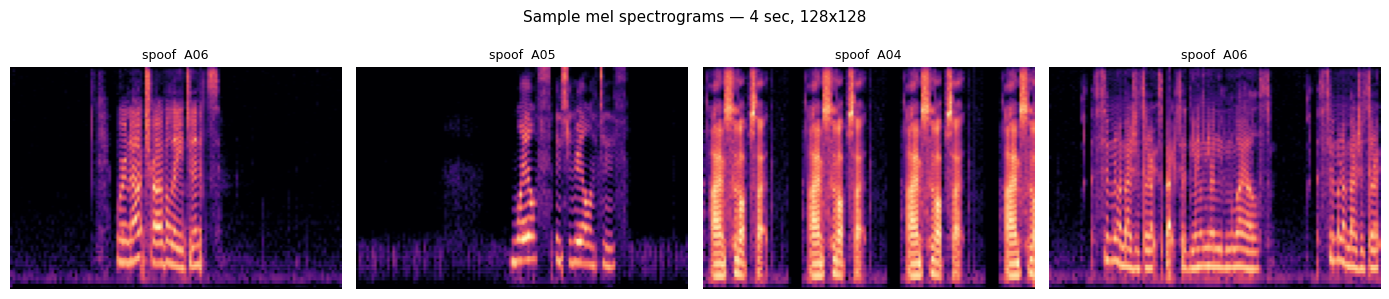

Sanity check PASSED.


In [8]:
# Cell 6 — Data sanity check
# Loads one batch and verifies shapes and values are correct.
# Must pass before proceeding to training.
print('Loading one batch...')
trl, dvl, evl = get_loaders()
mel_b, lbl_b, sys_b = next(iter(trl))

print(f'Train batch shape : {tuple(mel_b.shape)}  <- must be ({BATCH_SIZE}, 1, 128, 128)')
print(f'Labels sample     : {lbl_b[:8].tolist()}  (0=bonafide, 1=spoof)')
print(f'System IDs        : {list(sys_b[:4])}')
print(f'Value range       : [{mel_b.min():.2f}, {mel_b.max():.2f}]')
print(f'Train batches     : {len(trl)}')
print(f'Dev   batches     : {len(dvl)}')
print(f'Eval  batches     : {len(evl)}')

assert mel_b.shape == (BATCH_SIZE, 1, 128, 128), \
    f'Wrong shape: {mel_b.shape}. Expected ({BATCH_SIZE}, 1, 128, 128).'
print('Mel loader OK.')

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(mel_b[i, 0].numpy(), aspect='auto', origin='lower', cmap='magma')
    lab = 'bonafide' if lbl_b[i] == 0 else 'spoof'
    ax.set_title(f'{lab}  {sys_b[i]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Sample mel spectrograms — 4 sec, 128x128', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_mels.png'), dpi=120)
plt.show()
print('Sanity check PASSED.')


In [11]:
# Cell 7 — Model definitions

# ── Vanilla CNN Conv1D (Models 1 and 2) ───────────────────────────────────
# 4 conv blocks: Conv1d -> BN -> ReLU -> MaxPool
# Channels:      128 -> 128 -> 256 -> 256
# Time steps:    128 -> 64  -> 32  -> 16  -> 8
# Flatten:       256 × 8 = 2048
# FC1:           2048 -> 128 -> ReLU -> Dropout(0.5)
# FC2:           128  -> 2
# Input:         (batch, 1, 128, 128) mel -> squeezed to (batch, 128, 128)
# Parameters:    657,282
# Models 1 and 2 share this exact architecture.
# Only difference: Model 2 trains on augmented data.

class VanillaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        c = CNN_CHANNELS  # [128, 128, 256, 256]

        self.block1 = nn.Sequential(
            nn.Conv1d(N_MELS, c[0], kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(c[0]),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2))           # 128 -> 64

        self.block2 = nn.Sequential(
            nn.Conv1d(c[0], c[1], kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(c[1]),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2))           # 64 -> 32

        self.block3 = nn.Sequential(
            nn.Conv1d(c[1], c[2], kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(c[2]),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2))           # 32 -> 16

        self.block4 = nn.Sequential(
            nn.Conv1d(c[2], c[3], kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(c[3]),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2))           # 16 -> 8

        self.fc1  = nn.Linear(c[3] * 8, CNN_FC_HIDDEN)
        self.drop = nn.Dropout(0.5)
        self.fc2  = nn.Linear(CNN_FC_HIDDEN, 2)

    def forward(self, x):
        # x: (batch, 1, 128, 128) from mel loader
        x = x.squeeze(1)              # -> (batch, 128, 128)
        x = self.block4(self.block3(self.block2(self.block1(x))))
        return self.fc2(self.drop(F.relu(self.fc1(x.flatten(1)))))


# ── G-CNN C4 Conv2D (Model 3, e2cnn) ──────────────────────────────────────
# Same 4-block structure as VanillaCNN — architecturally fair comparison.
# C4 group: rotations by 0, 90, 180, 270 degrees.
# Field counts [8,16,32,32] x 4 rotations = [32,64,128,128] effective channels
# GroupPooling after block 4 collapses group dimension -> rotation invariant.
# After GroupPooling: 32 channels, flat_dim = 32×8×8 = 2048
# Parameters: 565,218 (verified by PyTorch)

class GCNN_C4(nn.Module):
    def __init__(self):
        super().__init__()
        f   = GCNN_FIELDS  # [8, 16, 32, 32]
        act = e2_gspaces.Rot2dOnR2(N=4)

        self.in_type = FieldType(act, [act.trivial_repr])
        t1 = FieldType(act, f[0] * [act.regular_repr])
        t2 = FieldType(act, f[1] * [act.regular_repr])
        t3 = FieldType(act, f[2] * [act.regular_repr])
        t4 = FieldType(act, f[3] * [act.regular_repr])

        self.c1 = e2nn.R2Conv(self.in_type, t1, 3, padding=1, bias=False)
        self.b1 = e2nn.InnerBatchNorm(t1)
        self.r1 = e2nn.ReLU(t1, inplace=True)
        self.p1 = e2nn.PointwiseMaxPool(t1, kernel_size=2, stride=2)

        self.c2 = e2nn.R2Conv(t1, t2, 3, padding=1, bias=False)
        self.b2 = e2nn.InnerBatchNorm(t2)
        self.r2 = e2nn.ReLU(t2, inplace=True)
        self.p2 = e2nn.PointwiseMaxPool(t2, kernel_size=2, stride=2)

        self.c3 = e2nn.R2Conv(t2, t3, 3, padding=1, bias=False)
        self.b3 = e2nn.InnerBatchNorm(t3)
        self.r3 = e2nn.ReLU(t3, inplace=True)
        self.p3 = e2nn.PointwiseMaxPool(t3, kernel_size=2, stride=2)

        self.c4 = e2nn.R2Conv(t3, t4, 3, padding=1, bias=False)
        self.b4 = e2nn.InnerBatchNorm(t4)
        self.r4 = e2nn.ReLU(t4, inplace=True)
        self.p4 = e2nn.PointwiseMaxPool(t4, kernel_size=2, stride=2)

        self.gpool = e2nn.GroupPooling(t4)
        self.fc1   = nn.Linear(f[3] * 8 * 8, 256)
        self.drop  = nn.Dropout(0.5)
        self.fc2   = nn.Linear(256, 2)

    def forward(self, x):
        x = GeometricTensor(x, self.in_type)
        x = self.p1(self.r1(self.b1(self.c1(x))))
        x = self.p2(self.r2(self.b2(self.c2(x))))
        x = self.p3(self.r3(self.b3(self.c3(x))))
        x = self.p4(self.r4(self.b4(self.c4(x))))
        x = self.gpool(x).tensor.flatten(1)
        return self.fc2(self.drop(F.relu(self.fc1(x))))


# ── SO(2) Equivariant Steerable CNN (Model 4, escnn) ──────────────────────
# Equivariant to continuous rotations — all angles, not just 90 degree steps.
# Filters defined as circular harmonic basis functions (steerable filters).
# Frequencies [0, 1, 2] — scalar, vector, quadrupole fields.
# Representation dimension per field: 1 + 2 + 2 = 5
# Field counts [6, 12, 24, 24] -> effective channels [30, 60, 120, 120]
# GroupPooling collapses SO(2) dimension -> rotation invariant output
# Parameters: computed dynamically by escnn

from escnn import gspaces
from escnn import nn as enn

class SteerableCNN_SO2(nn.Module):
    def __init__(self):
        super().__init__()

        # Define the geometric space — continuous rotations on the plane
        self.gspace = enn_gspaces.rot2dOnR2()

        # Define field types using circular harmonic frequencies [0, 1, 2]
        # Each field has representation dimension 1 + 2 + 2 = 5
        def make_field(n_fields):
            return enn.FieldType(
                self.gspace,
                n_fields * [self.gspace.irrep(0),
                            self.gspace.irrep(1),
                            self.gspace.irrep(2)]
            )

        # Input type — trivial representation (standard image)
        self.in_type = enn.FieldType(
            self.gspace,
            [self.gspace.trivial_repr]
        )

        # Field types for each block
        # [6, 12, 24, 24] fields x 5 dim = [30, 60, 120, 120] channels
        f = SO2_FIELDS
        t1 = make_field(f[0])
        t2 = make_field(f[1])
        t3 = make_field(f[2])
        t4 = make_field(f[3])

        # Block 1
        self.c1 = enn.R2Conv(self.in_type, t1,
                             kernel_size=3, padding=1, bias=False)
        self.b1 = enn.IIDBatchNorm2d(t1)
        self.r1 = enn.NormNonLinearity(t1)
        self.p1 = enn.NormMaxPool(t1, kernel_size=2, stride=2)

        # Block 2
        self.c2 = enn.R2Conv(t1, t2,
                             kernel_size=3, padding=1, bias=False)
        self.b2 = enn.IIDBatchNorm2d(t2)
        self.r2 = enn.NormNonLinearity(t2)
        self.p2 = enn.NormMaxPool(t2, kernel_size=2, stride=2)

        # Block 3
        self.c3 = enn.R2Conv(t2, t3,
                             kernel_size=3, padding=1, bias=False)
        self.b3 = enn.IIDBatchNorm2d(t3)
        self.r3 = enn.NormNonLinearity(t3)
        self.p3 = enn.NormMaxPool(t3, kernel_size=2, stride=2)

        # Block 4
        self.c4 = enn.R2Conv(t3, t4,
                             kernel_size=3, padding=1, bias=False)
        self.b4 = enn.IIDBatchNorm2d(t4)
        self.r4 = enn.NormNonLinearity(t4)
        self.p4 = enn.NormMaxPool(t4, kernel_size=2, stride=2)

        # Norm pooling — collapses SO(2) equivariance to invariance
        # Takes norm of each field vector -> invariant scalar per field
        self.norm_pool = enn.NormPool(t4)

        # After NormPool each field collapses to scalar
        # t4 has f[3] * 3 fields (3 irreps per field definition)
        # each becomes 1 scalar -> flat_dim = f[3] * 3 * 8 * 8
        flat_dim = f[3] * 3 * 8 * 8

        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.fc1  = nn.Linear(f[3] * 3, 256)
        self.drop = nn.Dropout(0.5)
        self.fc2  = nn.Linear(256, 2)

    def forward(self, x):
        x = enn.GeometricTensor(x, self.in_type)
        x = self.p1(self.r1(self.b1(self.c1(x))))
        x = self.p2(self.r2(self.b2(self.c2(x))))
        x = self.p3(self.r3(self.b3(self.c3(x))))
        x = self.p4(self.r4(self.b4(self.c4(x))))
        x = self.norm_pool(x).tensor
        x = self.gap(x).flatten(1)
        return self.fc2(self.drop(F.relu(self.fc1(x))))
                

def get_model(key):
    models = {
        'cnn'    : VanillaCNN,
        'gcnn'   : GCNN_C4,
        'steerable': SteerableCNN_SO2,
    }
    if key not in models:
        raise ValueError(f'Unknown model: {key}. Choose from {list(models)}')
    return models[key]()
    
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


print('Models defined.')
_cnn     = VanillaCNN()
_gcnn    = GCNN_C4()
_steerable = SteerableCNN_SO2()

print(f'Vanilla CNN params : {count_params(_cnn):>10,}')
print(f'G-CNN C4    params : {count_params(_gcnn):>10,}')
print(f'Steerable SO2 params   : {count_params(_steerable):>10,}')
print()

# CNN shape verification
_x = torch.zeros(2, 1, 128, 128)
_x = _x.squeeze(1)
for i, blk in enumerate([_cnn.block1, _cnn.block2,
                          _cnn.block3, _cnn.block4], 1):
    _x = blk(_x)
    print(f'  After CNN block {i}: {tuple(_x.shape)}')
print(f'  Flatten dim      : {_x.flatten(1).shape[1]}  (must be {CNN_CHANNELS[-1]*8})')
assert _x.flatten(1).shape[1] == CNN_CHANNELS[-1] * 8

# G-CNN shape verification
_gcnn = _gcnn.to('cpu')
_gx = GeometricTensor(torch.zeros(2, 1, 128, 128), _gcnn.in_type)
for i, (c, b, r, p) in enumerate([
        (_gcnn.c1, _gcnn.b1, _gcnn.r1, _gcnn.p1),
        (_gcnn.c2, _gcnn.b2, _gcnn.r2, _gcnn.p2),
        (_gcnn.c3, _gcnn.b3, _gcnn.r3, _gcnn.p3),
        (_gcnn.c4, _gcnn.b4, _gcnn.r4, _gcnn.p4)], 1):
    _gx = p(r(b(c(_gx))))
    print(f'  After G-CNN block {i}: tensor {tuple(_gx.tensor.shape)}')
_gx = _gcnn.gpool(_gx).tensor
print(f'  After GroupPool   : {tuple(_gx.shape)}')
print(f'  Flatten dim       : {_gx.flatten(1).shape[1]}  (must be 2048)')
assert _gx.flatten(1).shape[1] == GCNN_FIELDS[-1] * 8 * 8

# SO(2) Steerable CNN shape verification
_steerable = _steerable.to('cpu')
_sx = enn.GeometricTensor(torch.zeros(2, 1, 128, 128), _steerable.in_type)
for i, (c, b, r, p) in enumerate([
        (_steerable.c1, _steerable.b1, _steerable.r1, _steerable.p1),
        (_steerable.c2, _steerable.b2, _steerable.r2, _steerable.p2),
        (_steerable.c3, _steerable.b3, _steerable.r3, _steerable.p3),
        (_steerable.c4, _steerable.b4, _steerable.r4, _steerable.p4)], 1):
    _sx = p(r(b(c(_sx))))
    print(f'  After Steerable block {i}: tensor {tuple(_sx.tensor.shape)}')
_sx = _steerable.norm_pool(_sx).tensor
print(f'  After NormPool    : {tuple(_sx.shape)}')
print(f'  Flatten dim       : {_sx.flatten(1).shape[1]}  (must be {SO2_FIELDS[-1] * 3 * 8 * 8})')
assert _sx.flatten(1).shape[1] == SO2_FIELDS[-1] * 3 * 8 * 8

print('All model shapes verified.')

Models defined.
Vanilla CNN params :    657,282
G-CNN C4    params :    565,218
Steerable SO2 params   :     42,164

  After CNN block 1: (2, 128, 64)
  After CNN block 2: (2, 128, 32)
  After CNN block 3: (2, 256, 16)
  After CNN block 4: (2, 256, 8)
  Flatten dim      : 2048  (must be 2048)
  After G-CNN block 1: tensor (2, 32, 64, 64)
  After G-CNN block 2: tensor (2, 64, 32, 32)
  After G-CNN block 3: tensor (2, 128, 16, 16)
  After G-CNN block 4: tensor (2, 128, 8, 8)
  After GroupPool   : (2, 32, 8, 8)
  Flatten dim       : 2048  (must be 2048)
  After Steerable block 1: tensor (2, 30, 64, 64)
  After Steerable block 2: tensor (2, 60, 32, 32)
  After Steerable block 3: tensor (2, 120, 16, 16)
  After Steerable block 4: tensor (2, 120, 8, 8)
  After NormPool    : (2, 72, 8, 8)
  Flatten dim       : 4608  (must be 4608)
All model shapes verified.


In [ ]:
# Cell 8 — Metric functions

def compute_eer(labels, scores):
    # EER: threshold where False Alarm Rate == Miss Rate. Lower is better.
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1.0 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float(fpr[idx]), float(thresholds[idx])


def compute_min_dcf(labels, scores):
    # minDCF: minimum weighted error cost over all thresholds.
    # DCF(t) = C_miss * P(miss|t) * pi + C_fa * P(fa|t) * (1 - pi)
    # Normalised by cost of a trivial system. Computed from scores only.
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr  = 1.0 - tpr
    dcf  = (DCF_C_MISS * fnr * DCF_PI_SPOOF
          + DCF_C_FA   * fpr * (1.0 - DCF_PI_SPOOF))
    norm = min(DCF_C_MISS * DCF_PI_SPOOF,
               DCF_C_FA   * (1.0 - DCF_PI_SPOOF))
    return float(np.min(dcf) / norm)

def run_inference(model, loader):
    # Returns (labels_array, scores_array, system_ids_list)
    # scores = P(spoof) from softmax. Higher = more likely spoof.
    model.eval()
    all_labels, all_scores, all_sys = [], [], []
    with torch.no_grad():
        for mel, lbl, sys_id in loader:
            probs = torch.softmax(model(mel.to(DEVICE)), dim=1)[:, 1]
            all_labels.extend(lbl.numpy())
            all_scores.extend(probs.cpu().numpy())
            all_sys.extend(list(sys_id))
    return np.array(all_labels), np.array(all_scores), all_sys


print('Metric functions defined.')


In [ ]:
# Cell 9 — Training functions

def run_train_epoch(model, loader, optimiser, criterion):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for mel, lbl, _ in loader:
        mel, lbl = mel.to(DEVICE), lbl.to(DEVICE)
        optimiser.zero_grad()
        out  = model(mel)
        loss = criterion(out, lbl)
        loss.backward()
        optimiser.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == lbl).sum().item()
        n          += lbl.size(0)
    return total_loss / len(loader), correct / n


def run_val_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_l, all_s = 0.0, [], []
    with torch.no_grad():
        for mel, lbl, _ in loader:
            mel, lbl = mel.to(DEVICE), lbl.to(DEVICE)
            out = model(mel)
            total_loss += criterion(out, lbl).item()
            all_s.extend(torch.softmax(out, 1)[:, 1].cpu().numpy())
            all_l.extend(lbl.cpu().numpy())
    labels = np.array(all_l)
    scores = np.array(all_s)
    eer, _ = compute_eer(labels, scores)
    acc    = float(((scores >= 0.5).astype(int) == labels).mean())
    return total_loss / len(loader), acc, eer


def train_model(arch_key, display_name, ckpt_name,
                train_loader, dev_loader, n_epochs, patience,
                label_smoothing=0.0, weight_decay=1e-4):
    print(f'\n{"="*60}')
    print(f'  Training: {display_name}')
    print(f'{"="*60}')
    
    model = get_model(arch_key).to(DEVICE)
    
    # Weighted loss to handle class imbalance
    n_bonafide = sum(1 for _, l, _, _ in train_loader.dataset.samples if l == 0)
    n_spoof    = sum(1 for _, l, _, _ in train_loader.dataset.samples if l == 1)
    total      = n_bonafide + n_spoof
    w          = torch.tensor([total/n_bonafide, total/n_spoof]).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=w, label_smoothing=label_smoothing)
    print(f'  Class weights    : bonafide={w[0]:.3f}  spoof={w[1]:.3f}')

    optimiser = optim.Adam(model.parameters(),
                      lr=LR, weight_decay=weight_decay)
    warmup_epochs = getattr(train_loader.dataset, '_warmup', 0)
    _warmup_scheduler = optim.lr_scheduler.LinearLR(
        optimiser, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
    _main_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode='min', factor=0.5, patience=5)
    augmented = getattr(train_loader.dataset, 'augment', False)
    print(f'  Params       : {count_params(model):,}')
    print(f'  Train samples: {len(train_loader.dataset):,}  '
          f'({"augmented 3x" if augmented else "original only"})')
    print(f'  Dev   samples: {len(dev_loader.dataset):,}')

    best_eer, patience_c = float('inf'), 0
    ckpt_path = os.path.join(OUTPUT_DIR, f'{ckpt_name}_best.pt')
    log_path  = os.path.join(OUTPUT_DIR, f'{ckpt_name}_log.csv')

    with open(log_path, 'w', newline='') as f:
        csv.writer(f).writerow(
            ['epoch','tr_loss','tr_acc','val_loss','val_acc','val_eer','lr'])

    for epoch in range(1, n_epochs + 1):
        tr_l, tr_a         = run_train_epoch(model, train_loader,
                                             optimiser, criterion)
        vl_l, vl_a, vl_eer = run_val_epoch(model, dev_loader, criterion)
        # scheduler.step(vl_l)
        if epoch <= warmup_epochs:
            _warmup_scheduler.step()
        else:
            _main_scheduler.step(vl_l)
        lr   = optimiser.param_groups[0]['lr']
        flag = ''

        if vl_eer < best_eer:
            best_eer   = vl_eer
            patience_c = 0
            torch.save({'arch_key':    arch_key,
                        'state_dict':  model.state_dict(),
                        'val_eer':     vl_eer,
                        'epoch':       epoch}, ckpt_path)
            flag = '  <- best'
        else:
            patience_c += 1

        print(f'  Ep {epoch:3d}/{n_epochs} | '
              f'Tr L={tr_l:.4f} A={tr_a:.3f} | '
              f'Val L={vl_l:.4f} A={vl_a:.3f} EER={vl_eer:.4f} | '
              f'LR={lr:.1e}{flag}')

        with open(log_path, 'a', newline='') as f:
            csv.writer(f).writerow(
                [epoch, tr_l, tr_a, vl_l, vl_a, vl_eer, lr])

        if patience_c >= patience:
            print(f'  Early stopping at epoch {epoch}.')
            break

    # Copy checkpoint and log to Drive immediately after this model finishes
    print(f'  Best val EER : {best_eer:.4f}')
    print(f'  Checkpoint saved at: {ckpt_path}')
    return ckpt_path


print('Training functions defined.')


In [115]:
# Cell 9b — Cache train and dev only (eval loads from dataset)
print('Caching train 1.0x...')
cache_parallel('train', rates=[1.0], fraction=TRAIN_FRACTION, n_workers=1)

print('Caching train 0.8x...')
cache_parallel('train', rates=[0.8], fraction=TRAIN_FRACTION, n_workers=1)

print('Caching train 1.2x...')
cache_parallel('train', rates=[1.2], fraction=TRAIN_FRACTION, n_workers=1)

print('Caching dev...')
cache_parallel('dev', rates=[1.0], fraction=DEV_FRACTION, n_workers=1)

print('Train and dev caching complete. Eval loads from dataset.')

Caching train 1.0x...
  0/25380  done=0 skip=1 err=0
  500/25380  done=0 skip=501 err=0
  1000/25380  done=0 skip=1001 err=0
  1500/25380  done=0 skip=1501 err=0
  2000/25380  done=0 skip=2001 err=0
  2500/25380  done=0 skip=2501 err=0
  3000/25380  done=0 skip=3001 err=0
  3500/25380  done=0 skip=3501 err=0
  4000/25380  done=0 skip=4001 err=0
  4500/25380  done=0 skip=4501 err=0
  5000/25380  done=0 skip=5001 err=0
  5500/25380  done=0 skip=5501 err=0
  6000/25380  done=0 skip=6001 err=0
  6500/25380  done=0 skip=6501 err=0
  7000/25380  done=0 skip=7001 err=0
  7500/25380  done=0 skip=7501 err=0
  8000/25380  done=0 skip=8001 err=0
  8500/25380  done=0 skip=8501 err=0
  9000/25380  done=0 skip=9001 err=0
  9500/25380  done=0 skip=9501 err=0
  10000/25380  done=0 skip=10001 err=0
  10500/25380  done=0 skip=10501 err=0
  11000/25380  done=0 skip=11001 err=0
  11500/25380  done=0 skip=11501 err=0
  12000/25380  done=0 skip=12001 err=0
  12500/25380  done=0 skip=12501 err=0
  13000/2538

In [116]:
# Cell 10 — Run training
# ─────────────────────────────────────────────────────────────────────────
# QUICK_RUN = True  -> 3 epochs per model, sanity check only
# QUICK_RUN = False -> full training (up to 50 epochs, early stopping)
#
# Speed tips already applied:
#   - Mels loaded from cache (no on-the-fly computation)
#   - NUM_WORKERS=0 for stability on Kaggle
#   - Checkpoints saved locally to /kaggle/working/outputs
# ─────────────────────────────────────────────────────────────────────────
QUICK_RUN = False

_epochs   = 3  if QUICK_RUN else EPOCHS
_patience = 99 if QUICK_RUN else PATIENCE

if QUICK_RUN:
    print(f'QUICK_RUN mode: {_epochs} epochs only.')
    print('Set QUICK_RUN=False for full training.\n')

import time
t0 = time.time()

# ── Model 1: Vanilla CNN, original data ──────────────────────────────────
trl_orig, dvl, _ = get_loaders(augment_train=False)
m1_ckpt = train_model(
    arch_key='cnn',
    display_name='Model 1 - Vanilla CNN (original data)',
    ckpt_name='model1',
    train_loader=trl_orig,
    dev_loader=dvl,
    n_epochs=_epochs,
    patience=_patience,
)
print(f'Model 1 done in {(time.time()-t0)/60:.1f} min')

# ── Model 2: Vanilla CNN, augmented data ─────────────────────────────────
t1 = time.time()
trl_aug, dvl, _ = get_loaders(augment_train=True)
m2_ckpt = train_model(
    arch_key='cnn',
    display_name='Model 2 - Vanilla CNN (augmented: orig + 0.8x + 1.2x)',
    ckpt_name='model2',
    train_loader=trl_aug,
    dev_loader=dvl,
    n_epochs=_epochs,
    patience=_patience,
)
print(f'Model 2 done in {(time.time()-t1)/60:.1f} min')

# ── Model 3: G-CNN C4, original data ─────────────────────────────────────
t2 = time.time()
trl_orig, dvl, _ = get_loaders(augment_train=False)
m3_ckpt = train_model(
    arch_key='gcnn',
    display_name='Model 3 - G-CNN C4 (original data)',
    ckpt_name='model3',
    train_loader=trl_orig,
    dev_loader=dvl,
    n_epochs=_epochs,
    patience=_patience,
    label_smoothing=0.1,    # ADD THIS — was missing before
)
print(f'Model 3 done in {(time.time()-t2)/60:.1f} min')

# ── Model 4: SO(2) Equivariant Steerable CNN, original data ──────────────
t3 = time.time()
trl_orig, dvl, _ = get_loaders(augment_train=False)
trl_orig.dataset._warmup = 5   # tells scheduler to warm up 5 epochs
m4_ckpt = train_model(
    arch_key='steerable',
    display_name='Model 4 - SO(2) Equivariant Steerable CNN (original data)',
    ckpt_name='model4',
    train_loader=trl_orig,
    dev_loader=dvl,
    n_epochs=_epochs,        
    patience=_patience,        
    label_smoothing=0.1,
    weight_decay=1e-3,      # was 1e-3 in your last run — drop it way down
)
print(f'Model 4 done in {(time.time()-t3)/60:.1f} min')

print(f'\nTotal training time: {(time.time()-t0)/60:.1f} min')

print(f'm1_ckpt = {m1_ckpt}')
print(f'm2_ckpt = {m2_ckpt}')
print(f'm3_ckpt = {m3_ckpt}')
print(f'm4_ckpt = {m4_ckpt}')



  Training: Model 1 - Vanilla CNN (original data)
  Class weights    : bonafide=9.837  spoof=1.113
  Params       : 657,282
  Train samples: 25,380  (original only)
  Dev   samples: 24,844
  Ep   1/100 | Tr L=0.4440 A=0.775 | Val L=0.2791 A=0.858 EER=0.1044 | LR=1.0e-05  <- best
  Ep   2/100 | Tr L=0.1855 A=0.917 | Val L=0.0890 A=0.972 EER=0.0365 | LR=1.0e-05  <- best
  Ep   3/100 | Tr L=0.0676 A=0.980 | Val L=0.0411 A=0.987 EER=0.0216 | LR=1.0e-05  <- best
  Ep   4/100 | Tr L=0.0339 A=0.990 | Val L=0.0291 A=0.991 EER=0.0161 | LR=1.0e-05  <- best
  Ep   5/100 | Tr L=0.0193 A=0.996 | Val L=0.0196 A=0.994 EER=0.0110 | LR=1.0e-05  <- best
  Ep   6/100 | Tr L=0.0132 A=0.997 | Val L=0.0145 A=0.996 EER=0.0078 | LR=1.0e-05  <- best
  Ep   7/100 | Tr L=0.0078 A=0.998 | Val L=0.0125 A=0.996 EER=0.0071 | LR=1.0e-05  <- best
  Ep   8/100 | Tr L=0.0061 A=0.999 | Val L=0.0106 A=0.997 EER=0.0067 | LR=1.0e-05  <- best
  Ep   9/100 | Tr L=0.0050 A=0.999 | Val L=0.0135 A=0.995 EER=0.0063 | LR=1.0e-05 

In [117]:
# Cell 11 — Restore checkpoints if session restarted after training
# Run this instead of Cell 10 if your session restarted but checkpoints
# are still in /kaggle/working/outputs from the previous run.
# Kaggle preserves /kaggle/working/ within the same notebook session.

m1_ckpt = os.path.join(OUTPUT_DIR, 'model1_best.pt')
m2_ckpt = os.path.join(OUTPUT_DIR, 'model2_best.pt')
m3_ckpt = os.path.join(OUTPUT_DIR, 'model3_best.pt')
m4_ckpt = os.path.join(OUTPUT_DIR, 'model4_best.pt')

for name, path in [('Model 1', m1_ckpt),
                   ('Model 2', m2_ckpt),
                   ('Model 3', m3_ckpt),
                   ('Model 4', m4_ckpt)]:
    if os.path.exists(path):
        ckpt = torch.load(path, map_location='cpu', weights_only=True)
        print(f'  {name}: FOUND  '
              f'(best val EER: {ckpt["val_eer"]:.4f}, epoch {ckpt["epoch"]})')
    else:
        print(f'  {name}: NOT FOUND — retrain this model in Cell 10')


  Model 1: FOUND  (best val EER: 0.0012, epoch 41)
  Model 2: FOUND  (best val EER: 0.0012, epoch 14)
  Model 3: FOUND  (best val EER: 0.0012, epoch 78)
  Model 4: FOUND  (best val EER: 0.2253, epoch 60)


In [118]:
'''# Cell 11 — Load downloaded checkpoints
import os

UPLOADED_CKPT_DIR = '/kaggle/input/datasets/sam8452/trained-model'

print("Files in dataset:", os.listdir(UPLOADED_CKPT_DIR))

m1_ckpt = os.path.join(UPLOADED_CKPT_DIR, 'model1_best.pt')
m2_ckpt = os.path.join(UPLOADED_CKPT_DIR, 'model2_best.pt')
m3_ckpt = os.path.join(UPLOADED_CKPT_DIR, 'model3_best.pt')
#m4_ckpt = os.path.join(UPLOADED_CKPT_DIR, 'model4_best.pt')

for name, path in [('Model 1', m1_ckpt), ('Model 2', m2_ckpt),
                   ('Model 3', m3_ckpt), ('Model 4', m4_ckpt)]:
    if os.path.exists(path):
        ckpt = torch.load(path, map_location='cpu')
        print(f'  {name}: OK  '
              f'(val EER: {ckpt["val_eer"]:.4f}, '
              f'epoch {ckpt["epoch"]})')
    else:
        print(f'  {name}: NOT FOUND')'''

'# Cell 11 — Load downloaded checkpoints\nimport os\n\nUPLOADED_CKPT_DIR = \'/kaggle/input/datasets/sam8452/trained-model\'\n\nprint("Files in dataset:", os.listdir(UPLOADED_CKPT_DIR))\n\nm1_ckpt = os.path.join(UPLOADED_CKPT_DIR, \'model1_best.pt\')\nm2_ckpt = os.path.join(UPLOADED_CKPT_DIR, \'model2_best.pt\')\nm3_ckpt = os.path.join(UPLOADED_CKPT_DIR, \'model3_best.pt\')\n#m4_ckpt = os.path.join(UPLOADED_CKPT_DIR, \'model4_best.pt\')\n\nfor name, path in [(\'Model 1\', m1_ckpt), (\'Model 2\', m2_ckpt),\n                   (\'Model 3\', m3_ckpt), (\'Model 4\', m4_ckpt)]:\n    if os.path.exists(path):\n        ckpt = torch.load(path, map_location=\'cpu\')\n        print(f\'  {name}: OK  \'\n              f\'(val EER: {ckpt["val_eer"]:.4f}, \'\n              f\'epoch {ckpt["epoch"]})\')\n    else:\n        print(f\'  {name}: NOT FOUND\')'

In [120]:
# Cell 12 — FAST Evaluation using precomputed mel spectrograms
EVAL_PROTO = os.path.join(
    DATASET_ROOT,
    'ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt'
)

MODELS_EVAL = [
    ('model1', 'cnn',     'Model 1 CNN original',            m1_ckpt),
    ('model2', 'cnn',     'Model 2 CNN augmented',           m2_ckpt),
    ('model3', 'gcnn',    'Model 3 G-CNN C4',                m3_ckpt),
    ('model4', 'steerable', 'Model 4 SO(2) Steerable CNN',   m4_ckpt),
]

CONDITIONS = [
    ('original', 1.0,            '(i) Original'),
    ('slow',     TEST_RATE_SLOW, f'(ii-a) Slow {TEST_RATE_SLOW:.2f}x'),
    ('fast',     TEST_RATE_FAST, f'(ii-b) Fast {TEST_RATE_FAST:.2f}x'),
]

print(f'EVALUATION\n{"="*62}')

# PRELOAD ALL LOADERS ONCE (BIG SPEED BOOST)
eval_loaders = {}
for ckey, stretch, cname in CONDITIONS:
    print(f'Preparing loader: {cname}')
    eval_loaders[ckey] = get_precomputed_loader(stretch)

all_results = {}

# MODEL LOOP
for mkey, arch_key, mname, ckpt_path in MODELS_EVAL:
    if not os.path.exists(ckpt_path):
        print(f'  Checkpoint missing: {ckpt_path}')
        continue

    # FIXED: removed weights_only=True
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)

    model = get_model(arch_key).to(DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    all_results[mkey] = {}

    print(f'\n  {mname}  (best val EER: {ckpt["val_eer"]:.4f})')

    # CONDITION LOOP (reuses loaders)
    for ckey, stretch, cname in CONDITIONS:
        evl = eval_loaders[ckey]

        print(f'    Running {cname}...')
        labels, scores, sys_ids = run_inference(model, evl)

        eer, eer_thr = compute_eer(labels, scores)
        mdcf         = compute_min_dcf(labels, scores)

        all_results[mkey][ckey] = {
            'labels':    labels,
            'scores':    scores,
            'sys_ids':   sys_ids,
            'eer':       eer,
            'eer_thr':   eer_thr,
            'min_dcf':   mdcf,
            'cond_name': cname,
        }

        print(f'    {cname:<22}  EER: {eer*100:.2f}%  minDCF: {mdcf:.4f}')

print(f'\n{"="*62}\nEvaluation complete.')


# ── Real-world augmentation evaluation ───────────────────────────────────

AUGMENTED_CONDITIONS = [
    ('noise_20db', '(iii-a) Noise 20dB SNR'),
    ('noise_10db', '(iii-b) Noise 10dB SNR'),
    ('noise_0db',  '(iii-c) Noise 0dB SNR'),
    ('dropout',    '(iv)    Audio Dropout'),
]

print(f'\nAUGMENTED EVALUATION\n{"="*62}')

for mkey, arch_key, mname, ckpt_path in MODELS_EVAL:
    if not os.path.exists(ckpt_path):
        continue

    ckpt  = torch.load(ckpt_path, map_location=DEVICE)

    model = get_model(arch_key).to(DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    print(f'\n  {mname}')

    for aug_key, aug_name in AUGMENTED_CONDITIONS:
        print(f'    Running {aug_name}...')

        # NOTE: this still uses on-the-fly processing (you can optimize later)
        evl = get_augmented_eval_loader(aug_key, fraction=1.0)

        labels, scores, sys_ids = run_inference(model, evl)

        eer, _ = compute_eer(labels, scores)
        mdcf   = compute_min_dcf(labels, scores)

        print(f'    {aug_name:<28}  EER: {eer*100:.2f}%  minDCF: {mdcf:.4f}')

        if mkey not in all_results:
            all_results[mkey] = {}

        all_results[mkey][aug_key] = {
            'labels'   : labels,
            'scores'   : scores,
            'sys_ids'  : sys_ids,
            'eer'      : eer,
            'min_dcf'  : mdcf,
            'cond_name': aug_name,
        }

print(f'\n{"="*62}\nAugmented evaluation complete.')

EVALUATION
Preparing loader: (i) Original
  Processed 0 protocol entries...
  Processed 5000 protocol entries...
  Processed 10000 protocol entries...
  Processed 15000 protocol entries...
  Processed 20000 protocol entries...
  Processed 25000 protocol entries...
  Processed 30000 protocol entries...
  Processed 35000 protocol entries...
  Processed 40000 protocol entries...
  Processed 45000 protocol entries...
  Processed 50000 protocol entries...
  Processed 55000 protocol entries...
  Processed 60000 protocol entries...
  Processed 65000 protocol entries...
  Processed 70000 protocol entries...
Loaded 71237 samples for rate=1.0
Preparing loader: (ii-a) Slow 0.77x
  Processed 0 protocol entries...
  Processed 5000 protocol entries...
  Processed 10000 protocol entries...
  Processed 15000 protocol entries...
  Processed 20000 protocol entries...
  Processed 25000 protocol entries...
  Processed 30000 protocol entries...
  Processed 35000 protocol entries...
  Processed 40000 protoc

In [121]:
# Cell 13 — Statistical significance testing
from scipy.stats import friedmanchisquare, wilcoxon, spearmanr
import pandas as pd

print('STATISTICAL TESTING')
print('=' * 62)

# ── Prepare EER matrix across all conditions and models ──────────────────
# Rows = conditions, Columns = models
# Use all conditions where all four models have results

all_conditions = (
    [ckey for ckey, _, _ in CONDITIONS] +
    [aug_key for aug_key, _ in AUGMENTED_CONDITIONS]
)

model_keys = ['model1', 'model2', 'model3', 'model4']
model_names = {
    'model1': 'CNN original',
    'model2': 'CNN augmented',
    'model3': 'G-CNN C4',
    'model4': 'SO(2) steerable CNN',
}

# Build EER matrix — shape (n_conditions, n_models)
eer_matrix = []
valid_conditions = []

for ckey in all_conditions:
    row = []
    valid = True
    for mkey in model_keys:
        if mkey in all_results and ckey in all_results[mkey]:
            row.append(all_results[mkey][ckey]['eer'] * 100)
        else:
            valid = False
            break
    if valid:
        eer_matrix.append(row)
        valid_conditions.append(ckey)

eer_matrix = np.array(eer_matrix)  # (n_conditions, 4)
print(f'Conditions used for testing : {len(valid_conditions)}')
print(f'Models                      : {len(model_keys)}')
print()

# ── 1. Friedman Test ──────────────────────────────────────────────────────
# Tests whether there is a significant difference among the four models
# across all conditions simultaneously
# H0: all models perform equally across conditions
print('1. Friedman Test')
print('-' * 40)
stat, p_friedman = friedmanchisquare(
    eer_matrix[:, 0],
    eer_matrix[:, 1],
    eer_matrix[:, 2],
    eer_matrix[:, 3]
)
print(f'   Statistic : {stat:.4f}')
print(f'   p-value   : {p_friedman:.6f}')
if p_friedman < 0.05:
    print(f'   Result    : Significant difference exists among models (p < 0.05)')
    print(f'               Proceeding to post-hoc pairwise Wilcoxon tests')
else:
    print(f'   Result    : No significant difference detected (p >= 0.05)')
print()

# ── 2. Post-hoc Wilcoxon Signed-Rank Tests ───────────────────────────────
# Pairwise comparisons between all model pairs
# Most important: Model 2 vs Model 3, Model 3 vs Model 4
print('2. Post-hoc Wilcoxon Signed-Rank Tests')
print('-' * 40)

pairs = [
    ('model1', 'model2', 'CNN original vs CNN augmented'),
    ('model1', 'model3', 'CNN original vs G-CNN C4'),
    ('model1', 'model4', 'CNN original vs SO(2) Steerable CNN'),
    ('model2', 'model3', 'CNN augmented vs G-CNN C4'),
    ('model2', 'model4', 'CNN augmented vs SO(2) Steerablee CNN'),
    ('model3', 'model4', 'G-CNN C4 vs SO(2) Steerable CNN'),
]

# Bonferroni correction for multiple comparisons
n_pairs      = len(pairs)
alpha        = 0.05
alpha_corrected = alpha / n_pairs
print(f'   Bonferroni corrected alpha : {alpha_corrected:.4f} ({n_pairs} comparisons)')
print()

wilcoxon_results = []
for mk1, mk2, pair_name in pairs:
    idx1 = model_keys.index(mk1)
    idx2 = model_keys.index(mk2)
    scores1 = eer_matrix[:, idx1]
    scores2 = eer_matrix[:, idx2]
    try:
        stat_w, p_w = wilcoxon(scores1, scores2)
        sig = 'significant' if p_w < alpha_corrected else 'not significant'
        print(f'   {pair_name}')
        print(f'   Statistic: {stat_w:.4f}  p-value: {p_w:.6f}  -> {sig}')
        print()
        wilcoxon_results.append({
            'pair': pair_name,
            'statistic': stat_w,
            'p_value': p_w,
            'significant': p_w < alpha_corrected
        })
    except Exception as e:
        print(f'   {pair_name} — could not compute: {e}')
        print()

# ── 3. Spearman Correlation — Noise Severity ─────────────────────────────
# Tests whether EER increases consistently as noise level increases
# per model — severity order: 20dB (mild) -> 10dB -> 0dB (severe)
print('3. Spearman Correlation — Noise Severity vs EER')
print('-' * 40)
print('   Tests whether EER degrades consistently as noise increases')
print()

noise_conditions = ['noise_20db', 'noise_10db', 'noise_0db']
# SNR values — lower SNR = more noise = higher expected EER
snr_values = [20, 10, 0]

for mkey in model_keys:
    noise_eers = []
    valid = True
    for nc in noise_conditions:
        if mkey in all_results and nc in all_results[mkey]:
            noise_eers.append(all_results[mkey][nc]['eer'] * 100)
        else:
            valid = False
            break
    if valid and len(noise_eers) == 3:
        corr, p_corr = spearmanr(snr_values, noise_eers)
        # Negative correlation expected — lower SNR -> higher EER
        print(f'   {model_names[mkey]}')
        print(f'   EERs at 20dB/10dB/0dB SNR : '
              f'{noise_eers[0]:.2f}% / {noise_eers[1]:.2f}% / {noise_eers[2]:.2f}%')
        print(f'   Spearman r : {corr:.4f}  p-value : {p_corr:.4f}')
        if p_corr < 0.05:
            direction = 'increases' if corr < 0 else 'decreases'
            print(f'   Result     : EER significantly {direction} with noise level')
        else:
            print(f'   Result     : No significant monotonic trend detected')
        print()

# ── Save results ──────────────────────────────────────────────────────────
stats_path = os.path.join(OUTPUT_DIR, 'statistical_tests.csv')
wilcoxon_df = pd.DataFrame(wilcoxon_results)
wilcoxon_df.to_csv(stats_path, index=False)
print(f'Statistical test results saved to {stats_path}')

STATISTICAL TESTING
Conditions used for testing : 7
Models                      : 4

1. Friedman Test
----------------------------------------
   Statistic : 12.4286
   p-value   : 0.006050
   Result    : Significant difference exists among models (p < 0.05)
               Proceeding to post-hoc pairwise Wilcoxon tests

2. Post-hoc Wilcoxon Signed-Rank Tests
----------------------------------------
   Bonferroni corrected alpha : 0.0083 (6 comparisons)

   CNN original vs CNN augmented
   Statistic: 0.0000  p-value: 0.015625  -> not significant

   CNN original vs G-CNN C4
   Statistic: 0.0000  p-value: 0.015625  -> not significant

   CNN original vs SO(2) Steerable CNN
   Statistic: 9.0000  p-value: 0.468750  -> not significant

   CNN augmented vs G-CNN C4
   Statistic: 10.0000  p-value: 0.578125  -> not significant

   CNN augmented vs SO(2) Steerablee CNN
   Statistic: 2.0000  p-value: 0.046875  -> not significant

   G-CNN C4 vs SO(2) Steerable CNN
   Statistic: 5.0000  p-value: 

In [122]:
# Cell 14 — Results summary table
header = (f'{"Model":<40} {"Condition":<22} '
          f'{"EER %":>8} {"minDCF":>10}')
print(header)
print('-' * len(header))
csv_rows = []
for mkey, _, mname, _ in MODELS_EVAL:
    if mkey not in all_results: continue
    for ckey, _, cname in CONDITIONS:
        if ckey not in all_results[mkey]: continue
        r        = all_results[mkey][ckey]
        eer_pct  = r['eer'] * 100
        mdcf_val = r['min_dcf']
        print(f'  {mname:<38} {cname:<22} '
              f'{eer_pct:>7.2f}%  {mdcf_val:>10.4f}')
        csv_rows.append({
            'model':     mname,
            'condition': cname,
            'eer_pct':   round(eer_pct, 4),
            'min_dcf':   round(mdcf_val, 6),
        })
tbl_path = os.path.join(OUTPUT_DIR, 'results_table.csv')
with open(tbl_path, 'w', newline='') as f:
    w = csv.DictWriter(f,
        fieldnames=['model','condition','eer_pct','min_dcf'])
    w.writeheader()
    w.writerows(csv_rows)
print(f'\nSaved: {tbl_path}')


Model                                    Condition                 EER %     minDCF
-----------------------------------------------------------------------------------
  Model 1 CNN original                   (i) Original             10.80%      0.7040
  Model 1 CNN original                   (ii-a) Slow 0.77x        12.32%      0.7360
  Model 1 CNN original                   (ii-b) Fast 1.36x        14.03%      0.7337
  Model 2 CNN augmented                  (i) Original              9.10%      0.7953
  Model 2 CNN augmented                  (ii-a) Slow 0.77x         9.97%      0.7872
  Model 2 CNN augmented                  (ii-b) Fast 1.36x        10.35%      0.6941
  Model 3 G-CNN C4                       (i) Original              8.05%      0.4959
  Model 3 G-CNN C4                       (ii-a) Slow 0.77x         7.82%      0.4581
  Model 3 G-CNN C4                       (ii-b) Fast 1.36x         8.95%      0.5627
  Model 4 SO(2) Steerable CNN            (i) Original             1

=== Figure Set A: Baseline models (M1, M2) ===


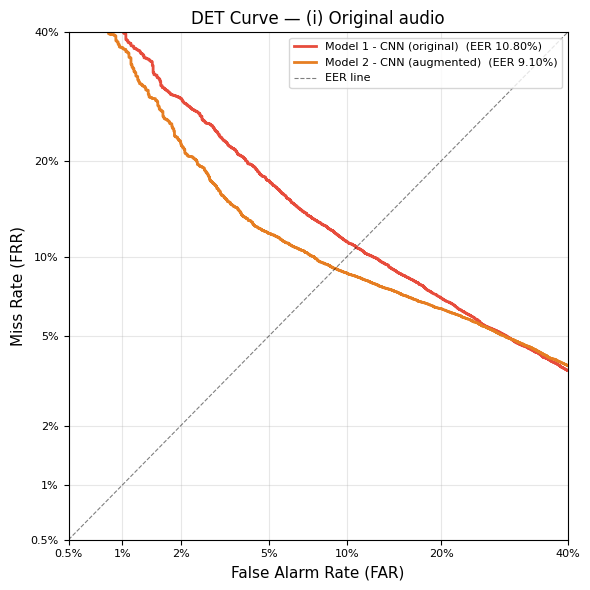

Saved: /kaggle/working/outputs/det_A_m1m2_original.png


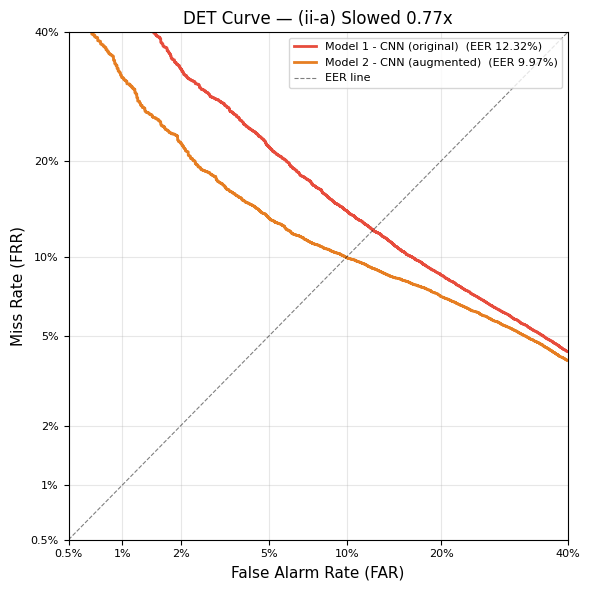

Saved: /kaggle/working/outputs/det_A_m1m2_slow.png


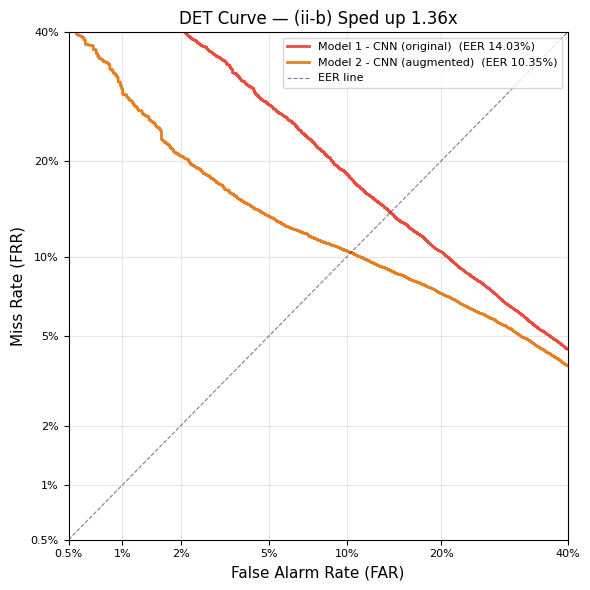

Saved: /kaggle/working/outputs/det_A_m1m2_fast.png
=== Figure Set B: G-CNN introduced (M1, M2, M3) ===


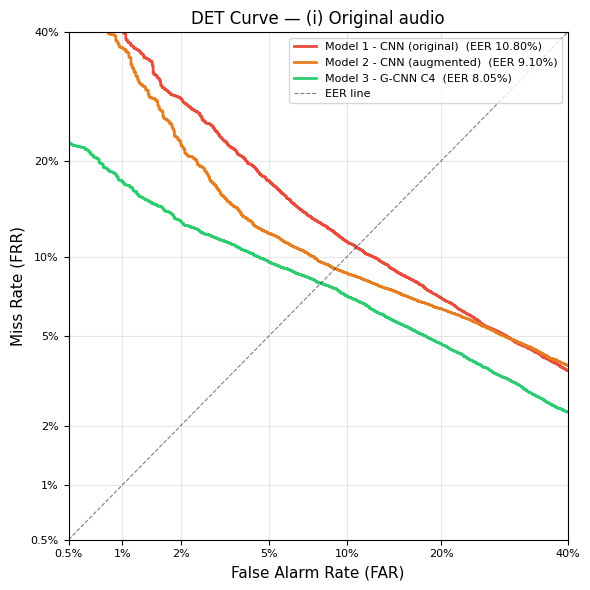

Saved: /kaggle/working/outputs/det_B_m1m2m3_original.png


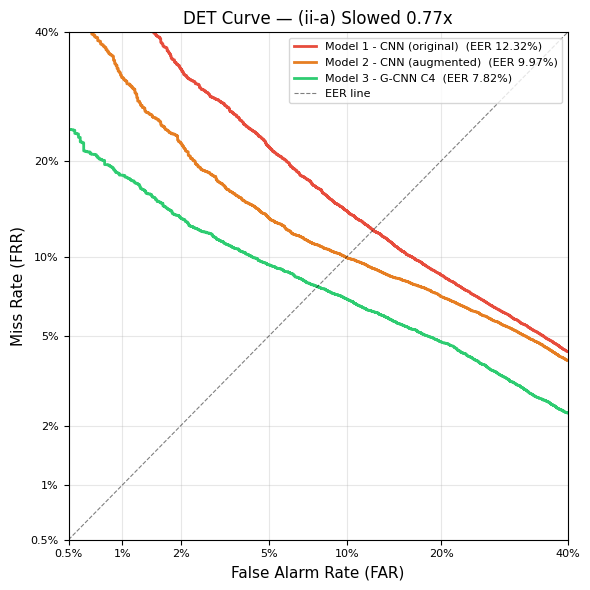

Saved: /kaggle/working/outputs/det_B_m1m2m3_slow.png


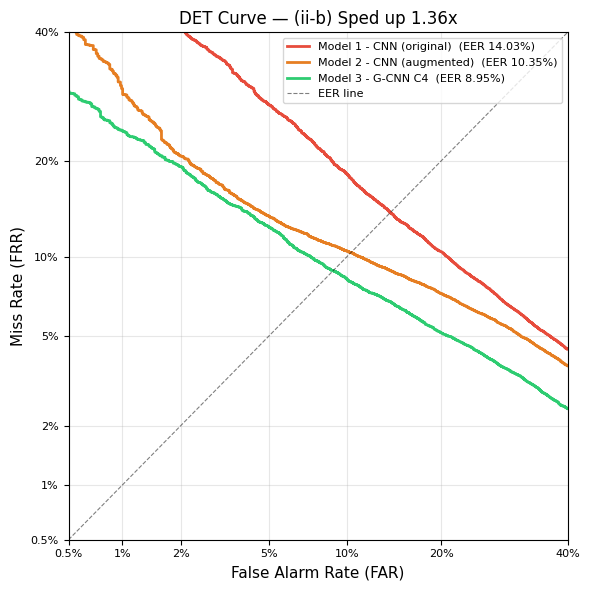

Saved: /kaggle/working/outputs/det_B_m1m2m3_fast.png
=== Figure Set C: All models (M1, M2, M3, M4) ===


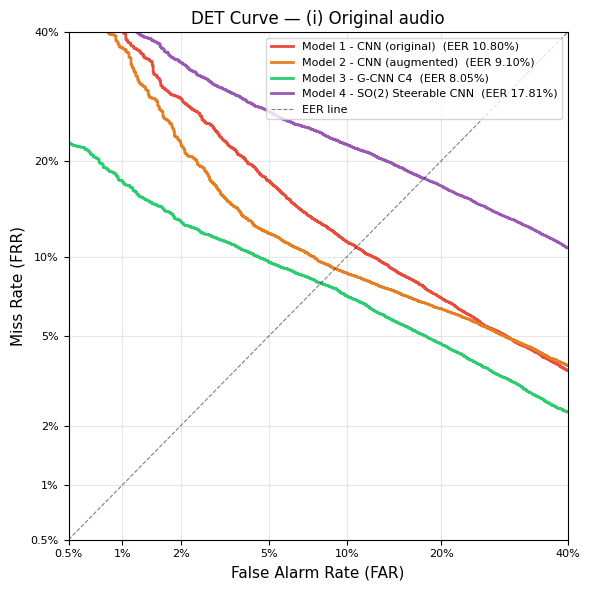

Saved: /kaggle/working/outputs/det_C_all_original.png


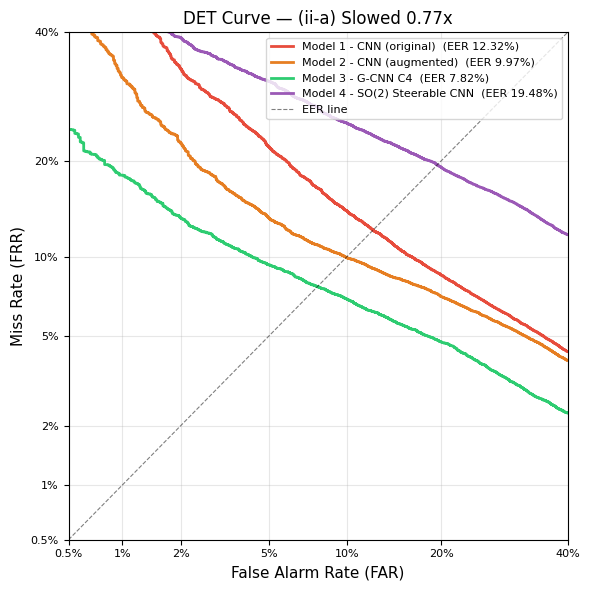

Saved: /kaggle/working/outputs/det_C_all_slow.png


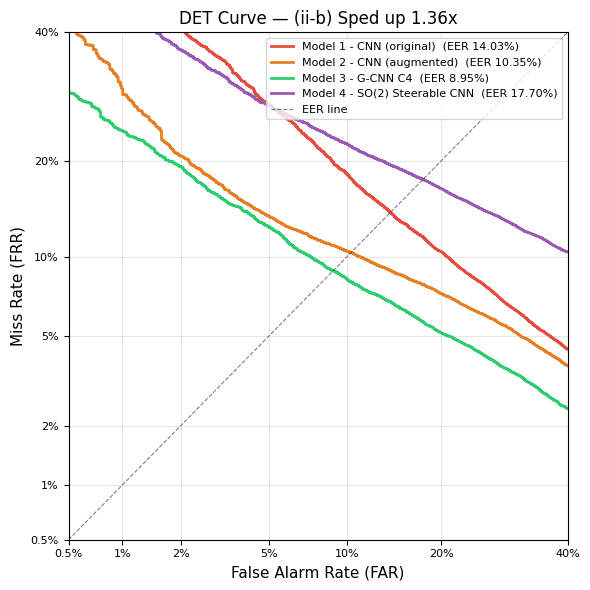

Saved: /kaggle/working/outputs/det_C_all_fast.png


In [124]:
# Cell 15 — DET plots
COLOURS = {
    'model1': '#E74C3C',
    'model2': '#E67E22',
    'model3': '#2ECC71',
    'model4': '#9B59B6',
}
MLABELS = {
    'model1': 'Model 1 - CNN (original)',
    'model2': 'Model 2 - CNN (augmented)',
    'model3': 'Model 3 - G-CNN C4',
    'model4': 'Model 4 - SO(2) Steerable CNN',
}
TICKS  = [0.5, 1, 2, 5, 10, 20, 40]
TICK_V = [scipy_norm.ppf(t / 100) for t in TICKS]

def plot_det(cond_key, title, filename, model_keys):
    fig, ax = plt.subplots(figsize=(6, 6))
    plotted = False
    for mkey in model_keys:
        if mkey not in all_results: continue
        if cond_key not in all_results[mkey]: continue
        r = all_results[mkey][cond_key]
        fpr, tpr, _ = roc_curve(r['labels'], r['scores'], pos_label=1)
        fnr = np.clip(1.0 - tpr, 1e-6, 1.0 - 1e-6)
        fpr = np.clip(fpr,       1e-6, 1.0 - 1e-6)
        lbl = f'{MLABELS[mkey]}  (EER {r["eer"]*100:.2f}%)'
        ax.plot(scipy_norm.ppf(fpr), scipy_norm.ppf(fnr),
                color=COLOURS[mkey], linewidth=2, label=lbl)
        plotted = True
    if not plotted:
        print(f'No data for {cond_key} — run Cell 12 first.')
        plt.close(); return
    ax.plot([TICK_V[0], TICK_V[-1]], [TICK_V[0], TICK_V[-1]],
            'k--', linewidth=0.8, alpha=0.5, label='EER line')
    ax.set_xticks(TICK_V); ax.set_xticklabels([f'{t}%' for t in TICKS], fontsize=8)
    ax.set_yticks(TICK_V); ax.set_yticklabels([f'{t}%' for t in TICKS], fontsize=8)
    ax.set_xlim(TICK_V[0], TICK_V[-1])
    ax.set_ylim(TICK_V[0], TICK_V[-1])
    ax.set_xlabel('False Alarm Rate (FAR)', fontsize=11)
    ax.set_ylabel('Miss Rate (FRR)', fontsize=11)
    ax.set_title(f'DET Curve — {title}', fontsize=12)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out}')


CONDITIONS_DET = [
    ('original', '(i) Original audio',           'original'),
    ('slow',     f'(ii-a) Slowed {TEST_RATE_SLOW:.2f}x', 'slow'),
    ('fast',     f'(ii-b) Sped up {TEST_RATE_FAST:.2f}x','fast'),
]

# ── Figure set A: Chapter 2 (baselines only) — M1 and M2 ─────────────────
print('=== Figure Set A: Baseline models (M1, M2) ===')
for cond_key, title, cname in CONDITIONS_DET:
    plot_det(
        cond_key, title,
        filename=f'det_A_m1m2_{cname}.png',
        model_keys=['model1', 'model2'],
    )

# ── Figure set B: Chapter 3 (G-CNN introduced) — M1, M2, M3 ─────────────
print('=== Figure Set B: G-CNN introduced (M1, M2, M3) ===')
for cond_key, title, cname in CONDITIONS_DET:
    plot_det(
        cond_key, title,
        filename=f'det_B_m1m2m3_{cname}.png',
        model_keys=['model1', 'model2', 'model3'],
    )

# ── Figure set C: Chapter 4 (all models) — M1, M2, M3, M4 ───────────────
print('=== Figure Set C: All models (M1, M2, M3, M4) ===')
for cond_key, title, cname in CONDITIONS_DET:
    plot_det(
        cond_key, title,
        filename=f'det_C_all_{cname}.png',
        model_keys=['model1', 'model2', 'model3', 'model4'],
    )

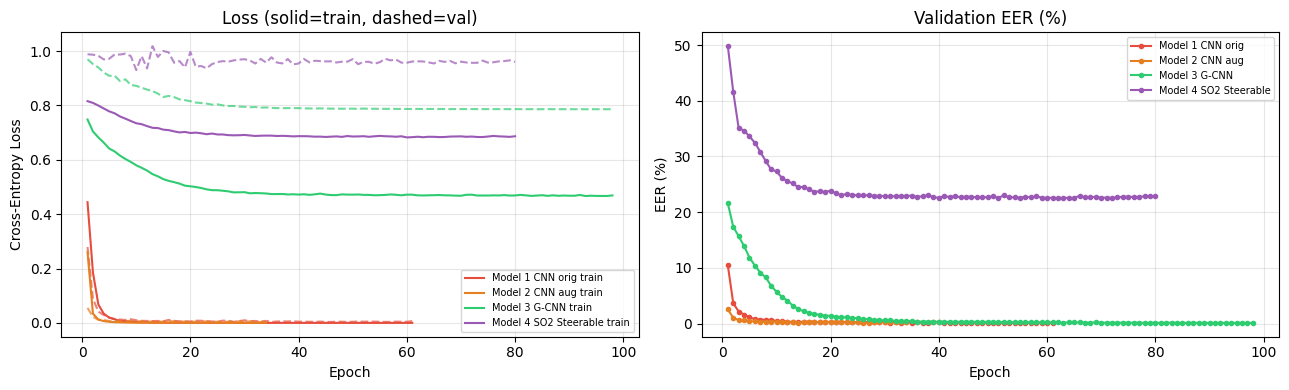

Saved: /kaggle/working/outputs/training_curves.png


In [125]:
# Cell 16 — Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
curve_info = [
    ('model1', '#E74C3C', 'Model 1 CNN orig'),
    ('model2', '#E67E22', 'Model 2 CNN aug'),
    ('model3', '#2ECC71', 'Model 3 G-CNN'),
    ('model4', '#9B59B6', 'Model 4 SO2 Steerable'),
]
any_plotted = False
for mkey, col, lbl in curve_info:
    log = os.path.join(OUTPUT_DIR, f'{mkey}_log.csv')
    if not os.path.exists(log):
        print(f'Log not found: {log}')
        continue
    with open(log) as f:
        rows = list(csv.DictReader(f))
    if not rows: continue
    ep      = [int(r['epoch'])         for r in rows]
    tr_loss = [float(r['tr_loss'])     for r in rows]
    vl_loss = [float(r['val_loss'])    for r in rows]
    vl_eer  = [float(r['val_eer'])*100 for r in rows]
    axes[0].plot(ep, tr_loss, color=col, linestyle='-',  label=f'{lbl} train')
    axes[0].plot(ep, vl_loss, color=col, linestyle='--', alpha=0.7)
    axes[1].plot(ep, vl_eer,  color=col, marker='o', markersize=3, label=lbl)
    any_plotted = True
if any_plotted:
    for ax, ttl, yl in zip(
            axes,
            ['Loss (solid=train, dashed=val)', 'Validation EER (%)'],
            ['Cross-Entropy Loss', 'EER (%)']):
        ax.set_title(ttl); ax.set_xlabel('Epoch'); ax.set_ylabel(yl)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, 'training_curves.png')
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out}')
else:
    print('No logs found. Run Cell 10 or Cell 11 first.')


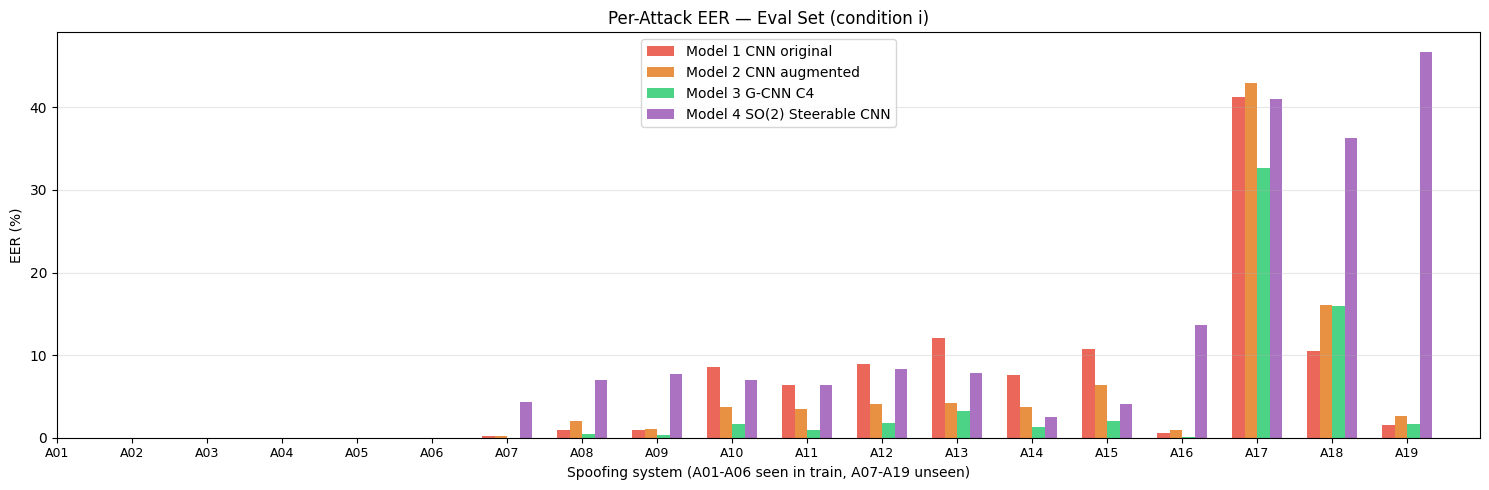

Saved: /kaggle/working/outputs/per_attack_eer.png


In [126]:
# Cell 17 — Per-attack EER (original condition)
# A01-A06: seen during training
# A07-A19: unseen — eval split only contains these

attack_systems = [f'A{i:02d}' for i in range(1, 20)]
bar_colours = ['#E74C3C', '#E67E22', '#2ECC71', '#9B59B6']
fig, ax = plt.subplots(figsize=(15, 5))
x, bw = np.arange(len(attack_systems)) * 1.5, 0.25
any_plotted = False

for j, (mkey, _, mname, _) in enumerate(MODELS_EVAL):
    if mkey not in all_results or 'original' not in all_results[mkey]:
        continue
    r       = all_results[mkey]['original']
    labels  = r['labels']
    scores  = r['scores']
    sys_arr = np.array(r['sys_ids'])
    eers    = []
    for atk in attack_systems:
        mask = (sys_arr == atk) | (labels == 0)
        if mask.sum() < 10:
            eers.append(float('nan'))
            continue
        try:
            e, _ = compute_eer(labels[mask], scores[mask])
            eers.append(e * 100)
        except Exception:
            eers.append(float('nan'))
    ax.bar(x + j * bw, eers, bw, label=mname,
           color=bar_colours[j], alpha=0.85)
    any_plotted = True

if any_plotted:
    ax.set_xticks(x + bw * 1.5)
    ax.set_xticklabels(attack_systems, fontsize=9)
    ax.set_xlabel('Spoofing system (A01-A06 seen in train, A07-A19 unseen)')
    ax.set_ylabel('EER (%)')
    ax.set_title('Per-Attack EER — Eval Set (condition i)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, 'per_attack_eer.png')
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out}')
else:
    print('No results found. Run Cell 12 first.')


In [ ]:
# Cell 18 — Final Clean Plots
import os
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------- DATA ---------------- #
all_results = {
    'model1': {
        'original': {'eer': 0.1080},
        'noise_20db': {'eer': 0.2291},
        'noise_10db': {'eer': 0.3429},
        'noise_0db':  {'eer': 0.4329},
        'dropout':    {'eer': 0.1187},
    },
    'model2': {
        'original': {'eer': 0.0910},
        'noise_20db': {'eer': 0.1963},
        'noise_10db': {'eer': 0.2661},
        'noise_0db':  {'eer': 0.3438},
        'dropout':    {'eer': 0.0953},
    },
    'model3': {
        'original': {'eer': 0.0805},
        'noise_20db': {'eer': 0.2283},
        'noise_10db': {'eer': 0.2939},
        'noise_0db':  {'eer': 0.3929},
        'dropout':    {'eer': 0.0809},
    },
    'model4': {
        'original': {'eer': 0.1781},
        'noise_20db': {'eer': 0.3135},
        'noise_10db': {'eer': 0.3040},
        'noise_0db':  {'eer': 0.2919},
        'dropout':    {'eer': 0.2133},
    }
}

COLOURS = {
    'model1': '#E74C3C',
    'model2': '#E67E22',
    'model3': '#2ECC71',
    'model4': '#9B59B6',
}

MLABELS = {
    'model1': 'Model 1',
    'model2': 'Model 2',
    'model3': 'Model 3',
    'model4': 'Model 4',
}

MLABELS_legend = {
    'model1': 'Model 1 - CNN (original)',
    'model2': 'Model 2 - CNN (augmented)',
    'model3': 'Model 3 - G-CNN C4',
    'model4': 'Model 4 - SO(2) Steerable CNN',
}

# ---------------- PLOT 1: NOISE CURVE ---------------- #
def plot_noise_curve():
    snr_labels = ['20dB', '10dB', '0dB']
    cond_keys  = ['noise_20db', 'noise_10db', 'noise_0db']

    fig, ax = plt.subplots(figsize=(7, 5.5))

    for idx, mkey in enumerate(MLABELS):
        eers = [all_results[mkey][ck]['eer'] * 100 for ck in cond_keys]

        ax.plot(
            snr_labels, eers,
            color=COLOURS[mkey],
            marker='o',
            markersize=6,
            markeredgecolor='black',
            linewidth=2.5,
            label=MLABELS_legend[mkey]
        )

        # annotations
        for i, v in enumerate(eers):
            direction = 1 if idx % 2 == 0 else -1
            offset = 1.0 * direction

            ax.text(
                i, v + offset,
                f'{v:.1f}%',
                ha='center',
                va='bottom' if direction > 0 else 'top',
                fontsize=8,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
            )

    ax.set_xlabel('Noise Level (SNR)', fontsize=11)
    ax.set_ylabel('EER (%)', fontsize=11)
    ax.set_title('Noise Robustness Curve', fontsize=12)

    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'noise_robustness_curve.png'), dpi=150)
    plt.show()

plot_noise_curve()


# ---------------- PLOT 2: DROPOUT ---------------- #
def plot_dropout_bar():
    fig, ax = plt.subplots(figsize=(7, 5))

    models = list(MLABELS.keys())
    eers = [all_results[m]['dropout']['eer'] * 100 for m in models]

    bars = ax.bar(
        [MLABELS[m] for m in models],
        eers,
        color=[COLOURS[m] for m in models]
    )

    # annotations
    for bar, v in zip(bars, eers):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            v + 0.4,
            f'{v:.1f}%',
            ha='center',
            fontsize=8
        )

    # 🔥 LEGEND (same style as plot 1)
    handles = [
        plt.Line2D([0], [0],
                   color=COLOURS[m],
                   lw=3,
                   label=MLABELS_legend[m])
        for m in models
    ]
    ax.legend(handles=handles, fontsize=8, loc='upper left')

    ax.set_ylabel('EER (%)', fontsize=11)
    ax.set_title('Performance under Audio Dropout', fontsize=12)

    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dropout_comparison.png'), dpi=150)
    plt.show()

plot_dropout_bar()

In [127]:
# Cell 19 — List all saved outputs
# All files in OUTPUT_DIR are downloadable from the Kaggle Output tab
# on the right panel after the session ends.
import glob
files = sorted(glob.glob(os.path.join(OUTPUT_DIR, '*')))
print(f'Output directory : {OUTPUT_DIR}')
print(f'Total files      : {len(files)}')
print()
total_mb = 0
for fp in files:
    size_kb = os.path.getsize(fp) / 1024
    size_mb = size_kb / 1024
    total_mb += size_mb
    print(f'  {os.path.basename(fp):<42}  {size_kb:>8.1f} KB')
print(f'\nTotal size: {total_mb:.1f} MB')
print('\nTo download: Kaggle right panel -> Output tab -> Download')


Output directory : /kaggle/working/outputs
Total files      : 22

  det_A_m1m2_fast.png                             82.1 KB
  det_A_m1m2_original.png                         81.3 KB
  det_A_m1m2_slow.png                             82.9 KB
  det_B_m1m2m3_fast.png                           98.3 KB
  det_B_m1m2m3_original.png                       96.6 KB
  det_B_m1m2m3_slow.png                           98.5 KB
  det_C_all_fast.png                             112.2 KB
  det_C_all_original.png                         111.6 KB
  det_C_all_slow.png                             112.6 KB
  model1_best.pt                                2582.9 KB
  model1_log.csv                                   6.3 KB
  model2_best.pt                                2582.9 KB
  model2_log.csv                                   3.7 KB
  model3_best.pt                                3174.0 KB
  model3_log.csv                                  10.2 KB
  model4_best.pt                                1424.6 KB
  mode